## Old Kernel, Manual KRR

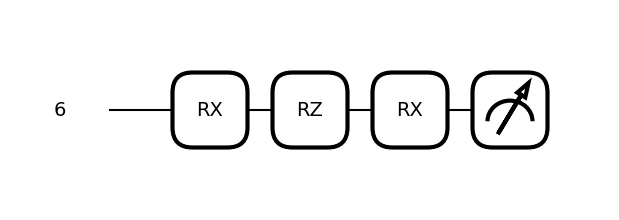

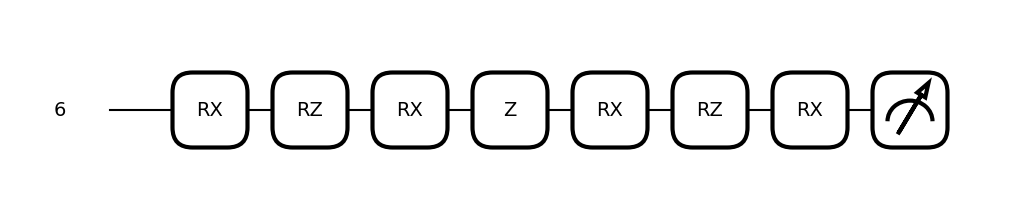

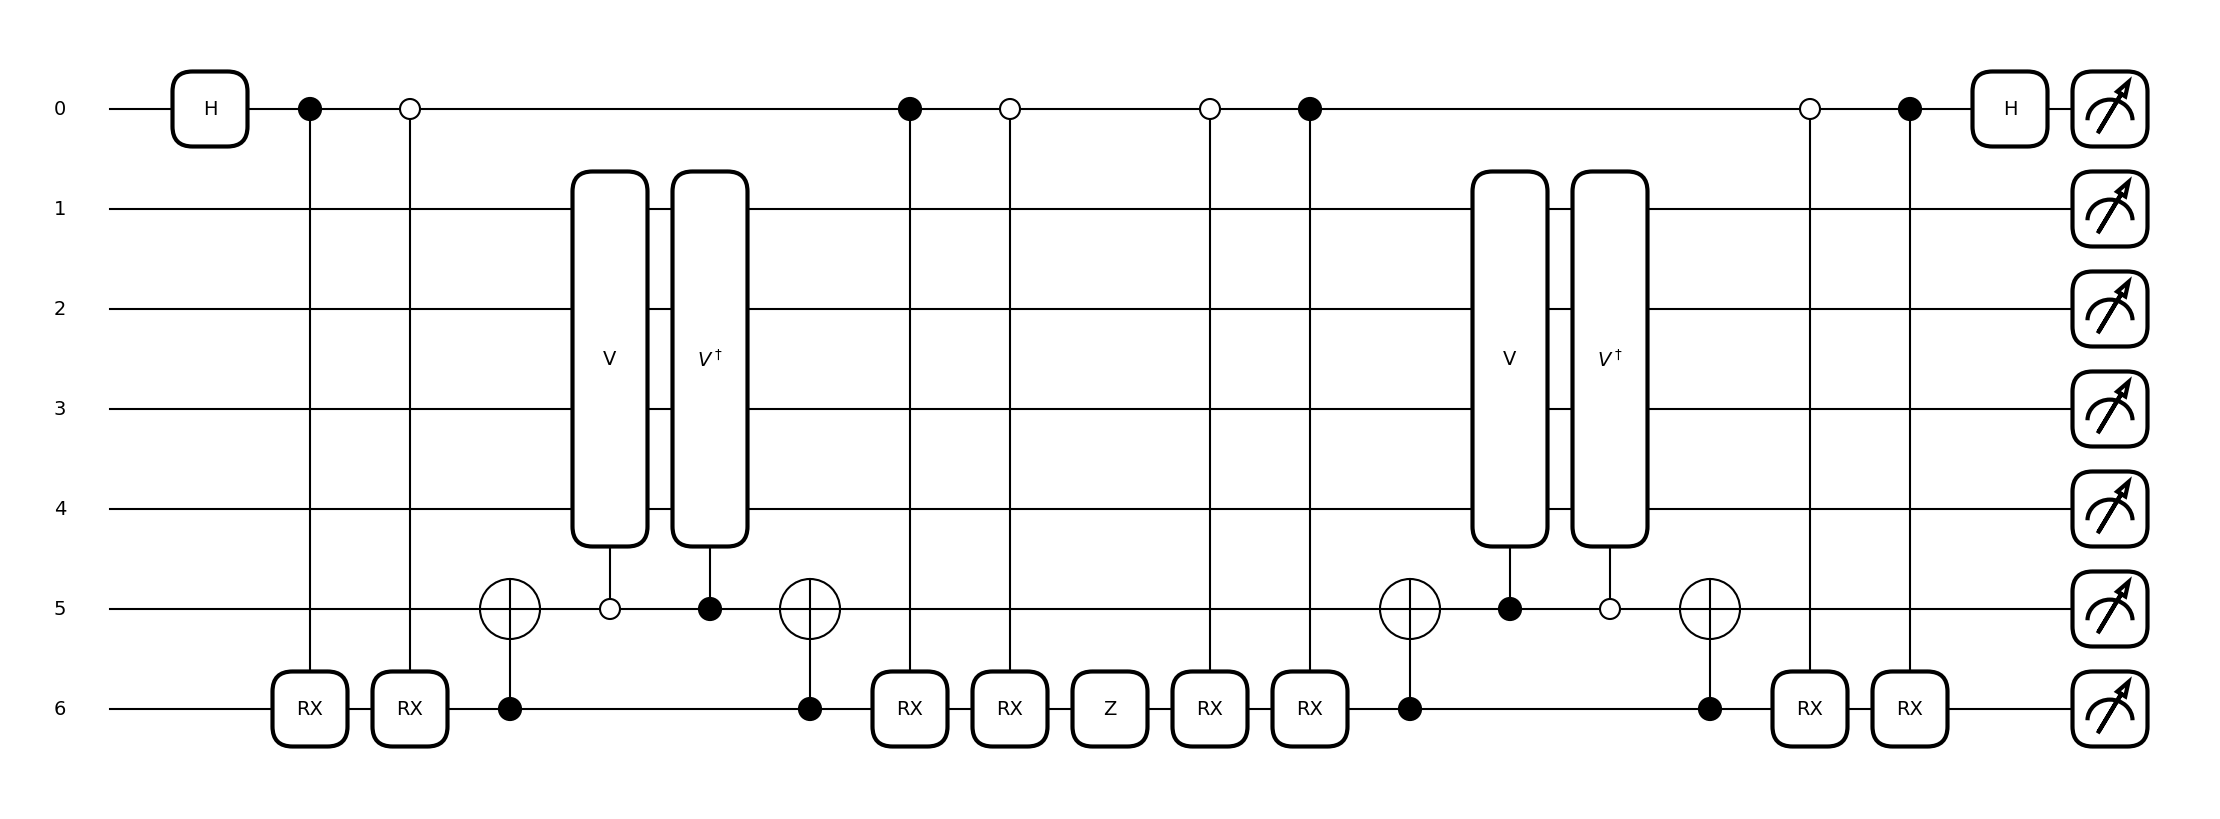

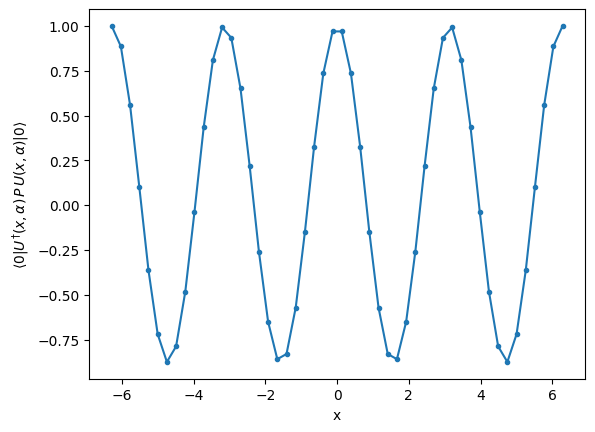

Computing train kernel: 100%|██████████| 40/40 [05:42<00:00,  8.55s/it]



Time to compute TRAIN kernel = 342.119 seconds



Computing test kernel: 100%|██████████| 10/10 [02:02<00:00, 12.21s/it]



Time to compute TEST kernel = 122.074 seconds

Time for manual Kernel Ridge Regression fit = 0.063 seconds

Train MSE = 0.0001503365388738767
Test MSE  = 0.004755999401339554
Train R2 = 0.9996426486020332
Test R2  = 0.991572820364689

Train Kernel:
[[1.         0.4140363  1.         ... 0.97049073 0.5824101  0.99213517]
 [0.41278806 1.         0.41301296 ... 0.57104976 0.97193059 0.49022185]
 [1.         0.411744   1.         ... 0.97070779 0.58428    0.99215759]
 ...
 [0.9704136  0.56963054 0.96996727 ... 1.         0.73230299 0.99296564]
 [0.58435541 0.97089419 0.58239134 ... 0.73229241 1.         0.66099274]
 [0.99225177 0.490713   0.99206348 ... 0.99276382 0.65917093 1.        ]]
Train-Test Kernel:
[[0.9992611  0.43449678 0.99930912 0.33848279 0.77623605 0.02816278
  0.33581872 0.77621047 0.96085243 0.83767697 0.68708248 0.52141907
  0.99966286 0.83822659 0.03885571 0.99898904 0.14373749 0.88967007
  0.52161974 0.14440908 0.26366607 0.99600323 1.         0.99944468
  0.60533874 0.

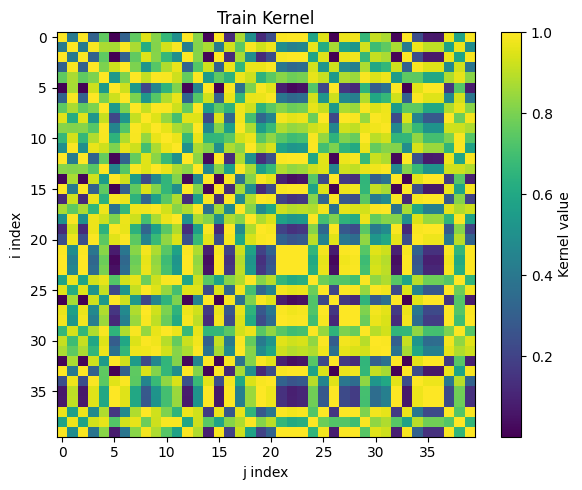

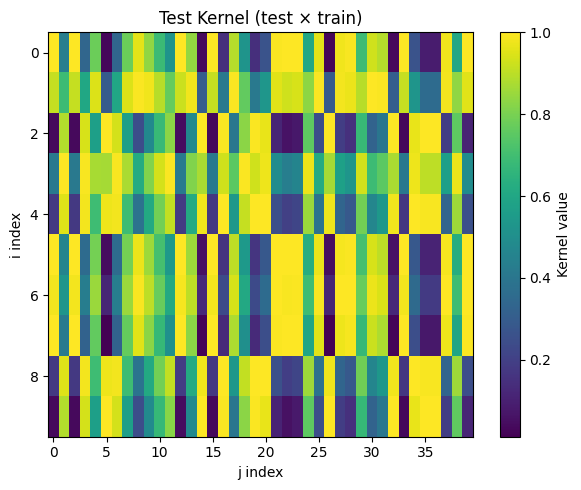

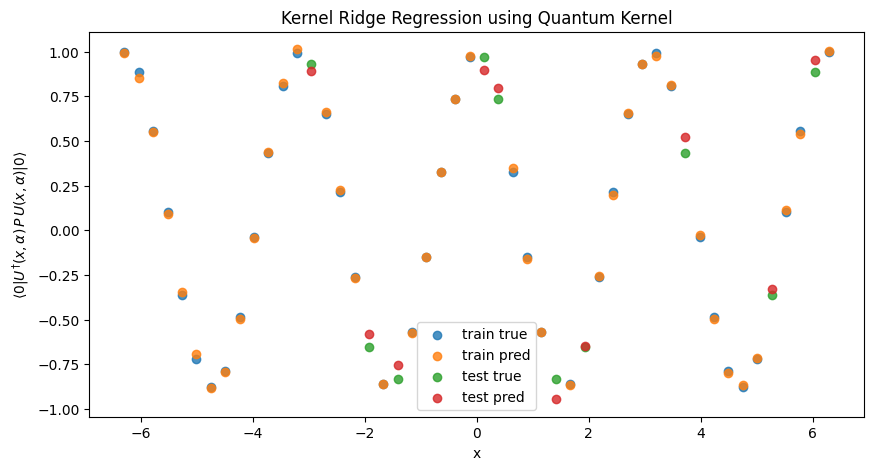

Min eigenvalue of train kernel: -0.009382885089497327


In [ ]:
import pennylane as qml
import numpy as np


from tqdm import tqdm
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error, r2_score


SEED = 42
np.random.seed(SEED)


# Wrapper gates for controlled Adders
class V(qml.operation.Operation):
    num_params = 2
    par_domain = "R"
    def __init__(self, value, wires, mod):
        super().__init__(value, mod, wires=wires)

    def decomposition(self):
        # Actual gate: controlled Adder
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]

# Adjoint version
class Vdagger(V):
    def __name__(self):
        return "V†"

    def decomposition(self):
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]
Vdagger.__name__ = r"$V^\dagger$"

dim_x=1
dim_alpha=1
observable_terms=['Z0']

# build_P function
def build_P(observable_terms):
    import pennylane as qml
    P = None
    for term in observable_terms:
        pieces = term.replace('+',' ').split()
        local = None
        for p in pieces:
            op = p[0].upper()
            idx = int(p[1:])
            t = getattr(qml, f'Pauli{op}')(idx)
            local = t if local is None else local @ t
        P = local if P is None else P + local
    return P if P is not None else qml.PauliZ(0)

def build_shifted_P(observable_terms, circ_offset):
            shifted_terms = []
            for term in observable_terms:
                parts = term.replace('+', ' ').split()
                new_parts = []
                for p in parts:
                    op = p[0].upper()
                    idx = int(p[1:])
                    new_parts.append(f"{op}{idx + circ_offset}")
                shifted_terms.append(" ".join(new_parts))
            return build_P(shifted_terms)
        
n_kernel=1; freq_register_sizes={0: 4}; n_freq=4
n_anc=1; n_circ=1; n_total=7
kernel_offset=0; freq_offset=1
anc_offset=5; circ_offset=6
shots = 1000000

dev=qml.device('default.qubit', wires=n_total, shots = shots, seed = SEED)
dev_analytic = qml.device('default.qubit', wires=n_total, shots=None)  # analytic

P_shifted = build_shifted_P(observable_terms, circ_offset=circ_offset)

def U(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)

@qml.qnode(dev_analytic)
def U_return_expval(x, α):
    U(x,α)
    return qml.expval(P_shifted)

@qml.qnode(dev)
def UPU(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)
    # user-provided adjoint (trimmed prefix)
    qml.RX(-x[0], wires=6)
    qml.RZ(-α[0], wires=6)
    qml.RX(-x[0], wires=6)
    return qml.state()

def AuPAu(x, x1, α):
    qml.Hadamard(wires=0)

    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [0])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [1])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)

    # Adjoint – reverse of duplicated U
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [1])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [0])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    qml.Hadamard(wires=0)


@qml.qnode(dev)
def AuPAu_sample(x, x1, α):
    AuPAu(x, x1, α)   # run your circuit
    return qml.sample(wires=range(n_total))


# Example caller
x0=np.zeros(dim_x); x1=np.copy(x0); α0=np.zeros(dim_alpha)
qml.draw_mpl(U_return_expval)(x0, α0); qml.draw_mpl(UPU)(x0, α0); qml.draw_mpl(AuPAu_sample)(x0, x1, α0);
plt.show();


def conditional_Z_kernel(x, x1, α):
    samples = AuPAu_sample(x, x1, α)

    # Extract each register
    kernel = samples[:, kernel_offset]     # wire 0
    anc = samples[:, anc_offset]           # anc wire
    circ = samples[:, circ_offset]         # circ wire

    # Condition: anc=0 and circ=0
    mask = (anc == 0) & (circ == 0)
    conditioned = kernel[mask]

    total = shots
    kept = conditioned.shape[0]

    if kept == 0:
        return {
            "total_shots": total,
            "kept_shots": 0,
            "expectation": None,
        }

    # convert bits to Z eigenvalues (+1 for 0, -1 for 1)
    zvals = 1 - 2*conditioned       # maps 0→+1, 1→−1

    return {
        "total_shots": total,
        "kept_shots": kept,
        "fraction_kept": kept / total,
        "expectation": np.mean(zvals),
    }

# -------------------------------------------------------
# Generate dataset
# -------------------------------------------------------
def generate_labels(X, α):
    Y = np.array([U_return_expval(x_arr, α) for x_arr in X])
    return Y


# Generated X (list of numpy arrays):
X = [np.array([-6.29]), np.array([-6.033265306122449]), np.array([-5.776530612244898]), np.array([-5.519795918367347]), np.array([-5.263061224489796]), np.array([-5.006326530612245]), np.array([-4.749591836734694]), np.array([-4.492857142857143]), np.array([-4.236122448979591]), np.array([-3.9793877551020405]), np.array([-3.7226530612244897]), np.array([-3.4659183673469385]), np.array([-3.2091836734693873]), np.array([-2.9524489795918365]), np.array([-2.6957142857142853]), np.array([-2.4389795918367345]), np.array([-2.1822448979591833]), np.array([-1.9255102040816325]), np.array([-1.6687755102040809]), np.array([-1.4120408163265301]), np.array([-1.1553061224489793]), np.array([-0.8985714285714277]), np.array([-0.6418367346938769]), np.array([-0.38510204081632615]), np.array([-0.1283673469387745]), np.array([0.12836734693877627]), np.array([0.38510204081632704]), np.array([0.6418367346938778]), np.array([0.8985714285714295]), np.array([1.1553061224489802]), np.array([1.412040816326531]), np.array([1.6687755102040827]), np.array([1.9255102040816334]), np.array([2.182244897959184]), np.array([2.438979591836735]), np.array([2.6957142857142857]), np.array([2.9524489795918383]), np.array([3.209183673469389]), np.array([3.46591836734694]), np.array([3.7226530612244906]), np.array([3.9793877551020413]), np.array([4.236122448979592]), np.array([4.492857142857145]), np.array([4.749591836734695]), np.array([5.006326530612246]), np.array([5.263061224489797]), np.array([5.519795918367348]), np.array([5.7765306122448985]), np.array([6.033265306122451]), np.array([6.29])]
alpha = np.array([0.5])
Y = generate_labels(X,alpha)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, shuffle = True, random_state = SEED)


if dim_x == 1:
    plt.plot(X, Y, ".-")
    plt.xlabel("x")
    plt.ylabel(r"$\langle 0 | U^{\dagger}(x,\alpha)\, P\, U(x,\alpha) | 0 \rangle$")
    plt.show();


# -------------------------------------------------------
# FUNCTION — compute train kernel (precomputed kernel)
# -------------------------------------------------------
def compute_kernel_matrix_train(X_train, α):
    n = len(X_train)
    K = np.zeros((n, n))

    for i in tqdm(range(n), desc="Computing train kernel"):
        for j in range(n):
            res = conditional_Z_kernel(X_train[i], X_train[j], α)
            K[i, j] = res["expectation"] if res["expectation"] is not None else 0.0

    return K


# -------------------------------------------------------
# FUNCTION — compute test kernel (test × train)
# -------------------------------------------------------
def compute_kernel_matrix_test(X_test, X_train, α):
    n_test = len(X_test)
    n_train = len(X_train)
    K = np.zeros((n_test, n_train))

    for i in tqdm(range(n_test), desc="Computing test kernel"):
        for j in range(n_train):
            res = conditional_Z_kernel(X_test[i], X_train[j], α)
            K[i, j] = res["expectation"] if res["expectation"] is not None else 0.0

    return K

# -------------------------------------------------------
# KERNEL COMPUTATION WITH TIMING
# -------------------------------------------------------
start_train = time.time()
K_train = compute_kernel_matrix_train(X_train, alpha)
end_train = time.time()
print(f"\nTime to compute TRAIN kernel = {end_train - start_train:.3f} seconds\n")

start_test = time.time()
K_test = compute_kernel_matrix_test(X_test, X_train, alpha)
end_test = time.time()
print(f"\nTime to compute TEST kernel = {end_test - start_test:.3f} seconds\n")

def manual_krr_fit(K_train, y_train, lam):
    """
    Manual kernel ridge regression fit.
    Works for real or complex kernels.
    """
    n = K_train.shape[0]
    return np.linalg.solve(K_train + lam * np.eye(n), y_train)


def manual_krr_predict(K_test, coeffs):
    """
    Predict using kernel matrix and fitted coefficients.
    """
    return K_test @ coeffs


# -------------------------------------------------------
# MANUAL KERNEL RIDGE REGRESSION
# -------------------------------------------------------
lam = 1e-3

start_krr = time.time()
coeffs = manual_krr_fit(K_train, Y_train, lam)
end_krr = time.time()

print(f"Time for manual Kernel Ridge Regression fit = {end_krr - start_krr:.3f} seconds\n")

Y_train_pred = manual_krr_predict(K_train, coeffs)
Y_test_pred  = manual_krr_predict(K_test, coeffs)


# -------------------------------------------------------
# METRICS
# -------------------------------------------------------
print("Train MSE =", mean_squared_error(Y_train, Y_train_pred))
print("Test MSE  =", mean_squared_error(Y_test, Y_test_pred))

print("Train R2 =", r2_score(Y_train, Y_train_pred))
print("Test R2  =", r2_score(Y_test, Y_test_pred))

# -------------------------------------------------------
# KERNELS
# -------------------------------------------------------
print("")
print("Train Kernel:")
print(K_train)
print("Train-Test Kernel:")
print(K_test)

def show_kernel_heatmap(K, title="Kernel Matrix"):
    plt.figure(figsize=(6, 5))
    plt.imshow(K, aspect='auto')
    plt.colorbar(label='Kernel value')
    plt.title(title)
    plt.xlabel("j index")
    plt.ylabel("i index")
    plt.tight_layout()
    plt.show()

show_kernel_heatmap(K_train, "Train Kernel")
show_kernel_heatmap(K_test, "Test Kernel (test × train)")
# -------------------------------------------------------
# PLOT RESULTS
# -------------------------------------------------------
if dim_x == 1:
    plt.figure(figsize=(10,5))
    plt.scatter([x[0] for x in X_train], Y_train, label="train true", alpha=0.8)
    plt.scatter([x[0] for x in X_train], Y_train_pred, label="train pred", alpha=0.8)

    plt.scatter([x[0] for x in X_test], Y_test, label="test true", alpha=0.8)
    plt.scatter([x[0] for x in X_test], Y_test_pred, label="test pred", alpha=0.8)

    plt.legend()
    plt.xlabel("x")
    plt.ylabel(r"$\langle 0 | U^{\dagger}(x,\alpha)\, P\, U(x,\alpha) | 0 \rangle$")
    plt.title("Kernel Ridge Regression using Quantum Kernel")
    plt.show()

eigvals = np.linalg.eigvalsh(K_train)
print("Min eigenvalue of train kernel:", eigvals.min())


## Old Kernel, Manual KRR, Vary lambda

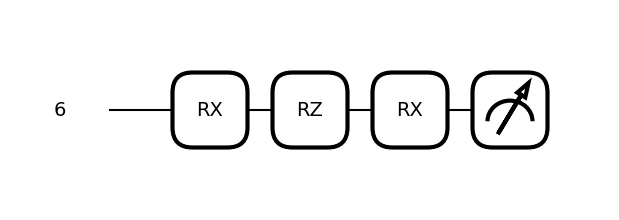

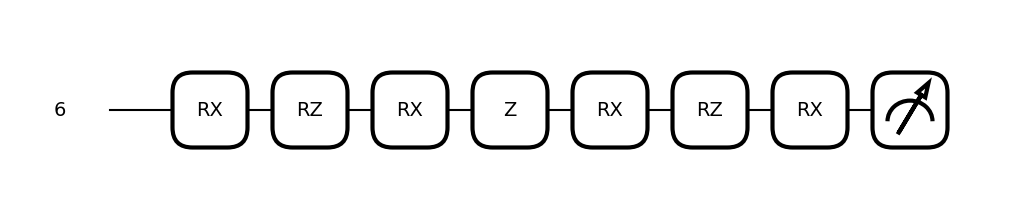

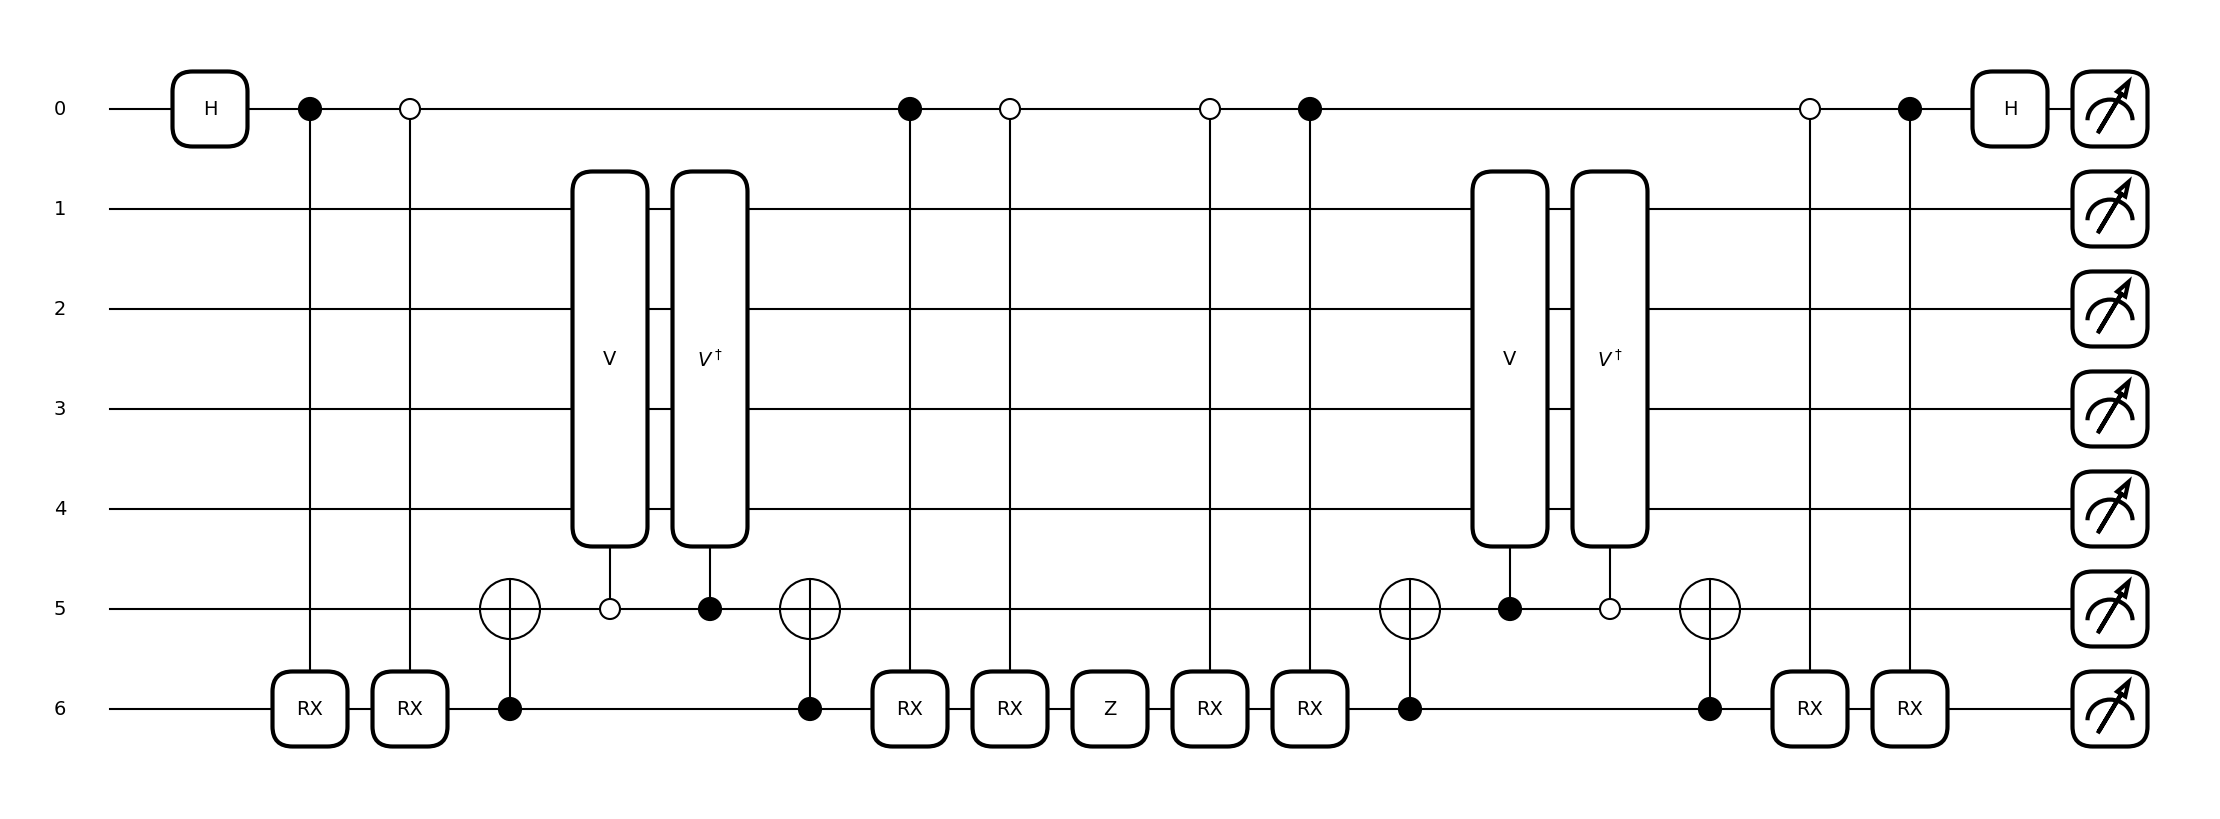

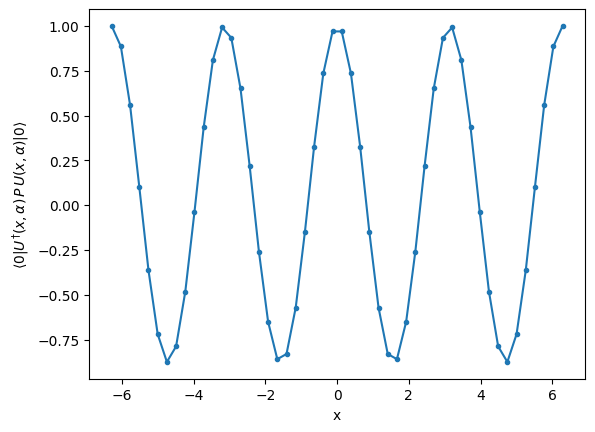

Computing train kernel: 100%|██████████| 40/40 [08:35<00:00, 12.90s/it]



Time to compute TRAIN kernel = 515.916 seconds



Computing test kernel: 100%|██████████| 10/10 [02:08<00:00, 12.86s/it]



Time to compute TEST kernel = 128.558 seconds



Sweeping lambda (KRR): 100%|██████████| 5/5 [00:00<00:00, 36.54λ/s]



Train Kernel:
[[1.         0.4140363  1.         ... 0.97049073 0.5824101  0.99213517]
 [0.41278806 1.         0.41301296 ... 0.57104976 0.97193059 0.49022185]
 [1.         0.411744   1.         ... 0.97070779 0.58428    0.99215759]
 ...
 [0.9704136  0.56963054 0.96996727 ... 1.         0.73230299 0.99296564]
 [0.58435541 0.97089419 0.58239134 ... 0.73229241 1.         0.66099274]
 [0.99225177 0.490713   0.99206348 ... 0.99276382 0.65917093 1.        ]]
Train-Test Kernel:
[[0.9992611  0.43449678 0.99930912 0.33848279 0.77623605 0.02816278
  0.33581872 0.77621047 0.96085243 0.83767697 0.68708248 0.52141907
  0.99966286 0.83822659 0.03885571 0.99898904 0.14373749 0.88967007
  0.52161974 0.14440908 0.26366607 0.99600323 1.         0.99944468
  0.60533874 0.96092754 0.02722274 0.97903581 0.98990176 0.68776113
  0.92801277 0.88893008 0.03730508 0.99906145 0.26302808 0.08924797
  0.08850407 0.97895811 0.60503546 0.99636397]
 [0.91335443 0.68773956 0.9126611  0.59893936 0.94857581 0.29419192

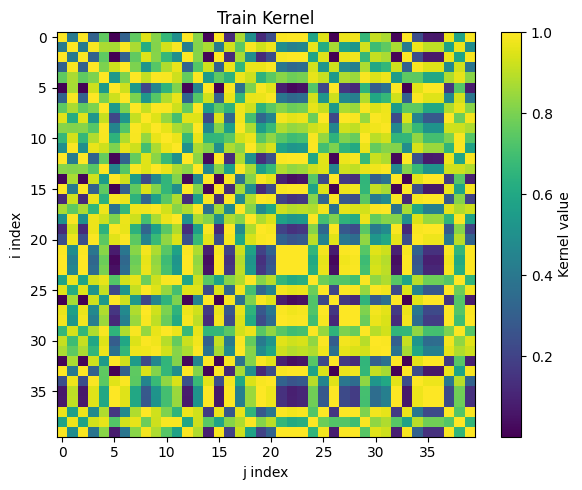

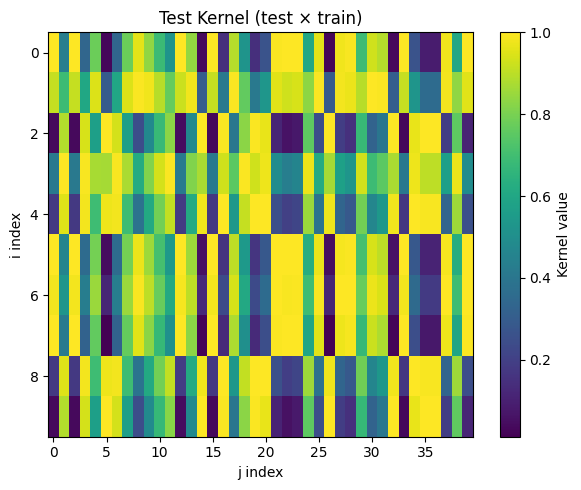

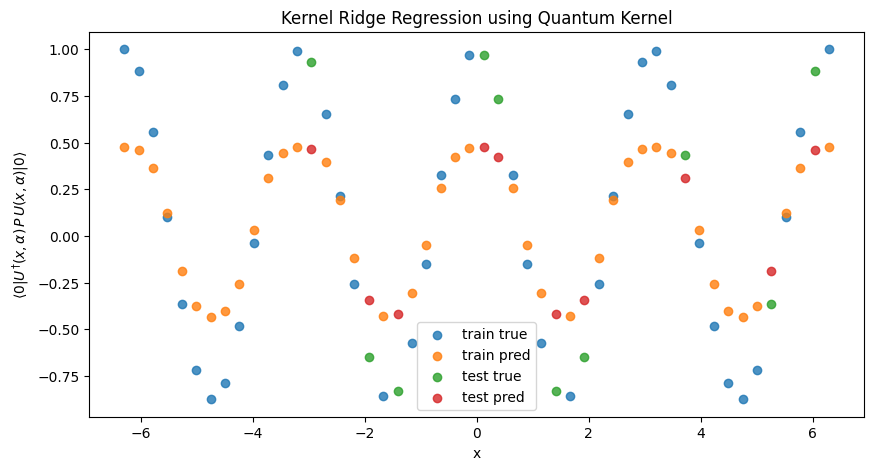

Min eigenvalue of train kernel: -0.009382885089497327


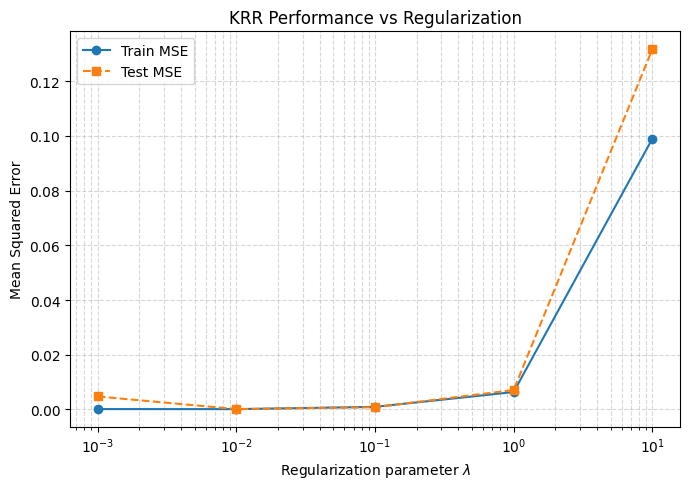

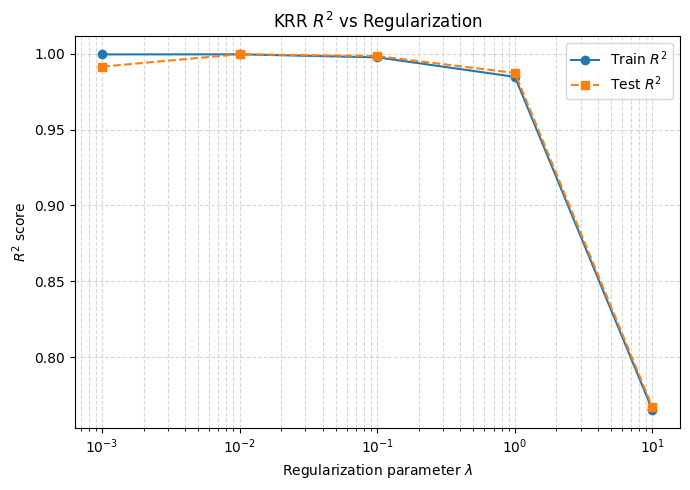

In [1]:
import pennylane as qml
import numpy as np


from tqdm import tqdm
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error, r2_score


SEED = 42
np.random.seed(SEED)


# Wrapper gates for controlled Adders
class V(qml.operation.Operation):
    num_params = 2
    par_domain = "R"
    def __init__(self, value, wires, mod):
        super().__init__(value, mod, wires=wires)

    def decomposition(self):
        # Actual gate: controlled Adder
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]

# Adjoint version
class Vdagger(V):
    def __name__(self):
        return "V†"

    def decomposition(self):
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]
Vdagger.__name__ = r"$V^\dagger$"

dim_x=1
dim_alpha=1
observable_terms=['Z0']

# build_P function
def build_P(observable_terms):
    import pennylane as qml
    P = None
    for term in observable_terms:
        pieces = term.replace('+',' ').split()
        local = None
        for p in pieces:
            op = p[0].upper()
            idx = int(p[1:])
            t = getattr(qml, f'Pauli{op}')(idx)
            local = t if local is None else local @ t
        P = local if P is None else P + local
    return P if P is not None else qml.PauliZ(0)

def build_shifted_P(observable_terms, circ_offset):
            shifted_terms = []
            for term in observable_terms:
                parts = term.replace('+', ' ').split()
                new_parts = []
                for p in parts:
                    op = p[0].upper()
                    idx = int(p[1:])
                    new_parts.append(f"{op}{idx + circ_offset}")
                shifted_terms.append(" ".join(new_parts))
            return build_P(shifted_terms)
        
n_kernel=1; freq_register_sizes={0: 4}; n_freq=4
n_anc=1; n_circ=1; n_total=7
kernel_offset=0; freq_offset=1
anc_offset=5; circ_offset=6
shots = 1000000

dev=qml.device('default.qubit', wires=n_total, shots = shots, seed = SEED)
dev_analytic = qml.device('default.qubit', wires=n_total, shots=None)  # analytic

P_shifted = build_shifted_P(observable_terms, circ_offset=circ_offset)

def U(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)

@qml.qnode(dev_analytic)
def U_return_expval(x, α):
    U(x,α)
    return qml.expval(P_shifted)

@qml.qnode(dev)
def UPU(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)
    # user-provided adjoint (trimmed prefix)
    qml.RX(-x[0], wires=6)
    qml.RZ(-α[0], wires=6)
    qml.RX(-x[0], wires=6)
    return qml.state()

def AuPAu(x, x1, α):
    qml.Hadamard(wires=0)

    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [0])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [1])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)

    # Adjoint – reverse of duplicated U
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [1])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [0])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    qml.Hadamard(wires=0)


@qml.qnode(dev)
def AuPAu_sample(x, x1, α):
    AuPAu(x, x1, α)   # run your circuit
    return qml.sample(wires=range(n_total))


# Example caller
x0=np.zeros(dim_x); x1=np.copy(x0); α0=np.zeros(dim_alpha)
qml.draw_mpl(U_return_expval)(x0, α0); qml.draw_mpl(UPU)(x0, α0); qml.draw_mpl(AuPAu_sample)(x0, x1, α0);
plt.show();


def conditional_Z_kernel(x, x1, α):
    samples = AuPAu_sample(x, x1, α)

    # Extract each register
    kernel = samples[:, kernel_offset]     # wire 0
    anc = samples[:, anc_offset]           # anc wire
    circ = samples[:, circ_offset]         # circ wire

    # Condition: anc=0 and circ=0
    mask = (anc == 0) & (circ == 0)
    conditioned = kernel[mask]

    total = shots
    kept = conditioned.shape[0]

    if kept == 0:
        return {
            "total_shots": total,
            "kept_shots": 0,
            "expectation": None,
        }

    # convert bits to Z eigenvalues (+1 for 0, -1 for 1)
    zvals = 1 - 2*conditioned       # maps 0→+1, 1→−1

    return {
        "total_shots": total,
        "kept_shots": kept,
        "fraction_kept": kept / total,
        "expectation": np.mean(zvals),
    }

# -------------------------------------------------------
# Generate dataset
# -------------------------------------------------------
def generate_labels(X, α):
    Y = np.array([U_return_expval(x_arr, α) for x_arr in X])
    return Y


# Generated X (list of numpy arrays):
X = [np.array([-6.29]), np.array([-6.033265306122449]), np.array([-5.776530612244898]), np.array([-5.519795918367347]), np.array([-5.263061224489796]), np.array([-5.006326530612245]), np.array([-4.749591836734694]), np.array([-4.492857142857143]), np.array([-4.236122448979591]), np.array([-3.9793877551020405]), np.array([-3.7226530612244897]), np.array([-3.4659183673469385]), np.array([-3.2091836734693873]), np.array([-2.9524489795918365]), np.array([-2.6957142857142853]), np.array([-2.4389795918367345]), np.array([-2.1822448979591833]), np.array([-1.9255102040816325]), np.array([-1.6687755102040809]), np.array([-1.4120408163265301]), np.array([-1.1553061224489793]), np.array([-0.8985714285714277]), np.array([-0.6418367346938769]), np.array([-0.38510204081632615]), np.array([-0.1283673469387745]), np.array([0.12836734693877627]), np.array([0.38510204081632704]), np.array([0.6418367346938778]), np.array([0.8985714285714295]), np.array([1.1553061224489802]), np.array([1.412040816326531]), np.array([1.6687755102040827]), np.array([1.9255102040816334]), np.array([2.182244897959184]), np.array([2.438979591836735]), np.array([2.6957142857142857]), np.array([2.9524489795918383]), np.array([3.209183673469389]), np.array([3.46591836734694]), np.array([3.7226530612244906]), np.array([3.9793877551020413]), np.array([4.236122448979592]), np.array([4.492857142857145]), np.array([4.749591836734695]), np.array([5.006326530612246]), np.array([5.263061224489797]), np.array([5.519795918367348]), np.array([5.7765306122448985]), np.array([6.033265306122451]), np.array([6.29])]
alpha = np.array([0.5])
Y = generate_labels(X,alpha)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, shuffle = True, random_state = SEED)


if dim_x == 1:
    plt.plot(X, Y, ".-")
    plt.xlabel("x")
    plt.ylabel(r"$\langle 0 | U^{\dagger}(x,\alpha)\, P\, U(x,\alpha) | 0 \rangle$")
    plt.show();


# -------------------------------------------------------
# FUNCTION — compute train kernel (precomputed kernel)
# -------------------------------------------------------
def compute_kernel_matrix_train(X_train, α):
    n = len(X_train)
    K = np.zeros((n, n))

    for i in tqdm(range(n), desc="Computing train kernel"):
        for j in range(n):
            res = conditional_Z_kernel(X_train[i], X_train[j], α)
            K[i, j] = res["expectation"] if res["expectation"] is not None else 0.0

    return K


# -------------------------------------------------------
# FUNCTION — compute test kernel (test × train)
# -------------------------------------------------------
def compute_kernel_matrix_test(X_test, X_train, α):
    n_test = len(X_test)
    n_train = len(X_train)
    K = np.zeros((n_test, n_train))

    for i in tqdm(range(n_test), desc="Computing test kernel"):
        for j in range(n_train):
            res = conditional_Z_kernel(X_test[i], X_train[j], α)
            K[i, j] = res["expectation"] if res["expectation"] is not None else 0.0

    return K

# -------------------------------------------------------
# KERNEL COMPUTATION WITH TIMING
# -------------------------------------------------------
start_train = time.time()
K_train = compute_kernel_matrix_train(X_train, alpha)
end_train = time.time()
print(f"\nTime to compute TRAIN kernel = {end_train - start_train:.3f} seconds\n")

start_test = time.time()
K_test = compute_kernel_matrix_test(X_test, X_train, alpha)
end_test = time.time()
print(f"\nTime to compute TEST kernel = {end_test - start_test:.3f} seconds\n")

def manual_krr_fit(K_train, y_train, lam):
    """
    Manual kernel ridge regression fit.
    Works for real or complex kernels.
    """
    n = K_train.shape[0]
    return np.linalg.solve(K_train + lam * np.eye(n), y_train)


def manual_krr_predict(K_test, coeffs):
    """
    Predict using kernel matrix and fitted coefficients.
    """
    return K_test @ coeffs


# -------------------------------------------------------
# MANUAL KERNEL RIDGE REGRESSION
# -------------------------------------------------------
lambdas = [1e-3, 1e-2, 1e-1, 1, 1e1]

train_mse = []
test_mse = []
train_r2 = []
test_r2 = []

for lam in tqdm(lambdas, desc="Sweeping lambda (KRR)",unit="λ"):
    # Fit
    coeffs = manual_krr_fit(K_train, Y_train, lam)

    # Predict
    Y_train_pred = manual_krr_predict(K_train, coeffs)
    Y_test_pred  = manual_krr_predict(K_test, coeffs)

    # Metrics
    train_mse.append(mean_squared_error(Y_train, Y_train_pred))
    test_mse.append(mean_squared_error(Y_test, Y_test_pred))

    train_r2.append(r2_score(Y_train, Y_train_pred))
    test_r2.append(r2_score(Y_test, Y_test_pred))







# -------------------------------------------------------
# KERNELS
# -------------------------------------------------------
print("")
print("Train Kernel:")
print(K_train)
print("Train-Test Kernel:")
print(K_test)

def show_kernel_heatmap(K, title="Kernel Matrix"):
    plt.figure(figsize=(6, 5))
    plt.imshow(K, aspect='auto')
    plt.colorbar(label='Kernel value')
    plt.title(title)
    plt.xlabel("j index")
    plt.ylabel("i index")
    plt.tight_layout()
    plt.show()

show_kernel_heatmap(K_train, "Train Kernel")
show_kernel_heatmap(K_test, "Test Kernel (test × train)")
# -------------------------------------------------------
# PLOT RESULTS
# -------------------------------------------------------
if dim_x == 1:
    plt.figure(figsize=(10,5))
    plt.scatter([x[0] for x in X_train], Y_train, label="train true", alpha=0.8)
    plt.scatter([x[0] for x in X_train], Y_train_pred, label="train pred", alpha=0.8)

    plt.scatter([x[0] for x in X_test], Y_test, label="test true", alpha=0.8)
    plt.scatter([x[0] for x in X_test], Y_test_pred, label="test pred", alpha=0.8)

    plt.legend()
    plt.xlabel("x")
    plt.ylabel(r"$\langle 0 | U^{\dagger}(x,\alpha)\, P\, U(x,\alpha) | 0 \rangle$")
    plt.title("Kernel Ridge Regression using Quantum Kernel")
    plt.show()

eigvals = np.linalg.eigvalsh(K_train)
print("Min eigenvalue of train kernel:", eigvals.min())

plt.figure(figsize=(7,5))
plt.plot(lambdas, train_mse, "o-", label="Train MSE")
plt.plot(lambdas, test_mse,  "s--", label="Test MSE")

plt.xscale("log")
plt.xlabel(r"Regularization parameter $\lambda$")
plt.ylabel("Mean Squared Error")
plt.title("KRR Performance vs Regularization")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
plt.plot(lambdas, train_r2, "o-", label="Train $R^2$")
plt.plot(lambdas, test_r2,  "s--", label="Test $R^2$")

plt.xscale("log")
plt.xlabel(r"Regularization parameter $\lambda$")
plt.ylabel(r"$R^2$ score")
plt.title("KRR $R^2$ vs Regularization")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


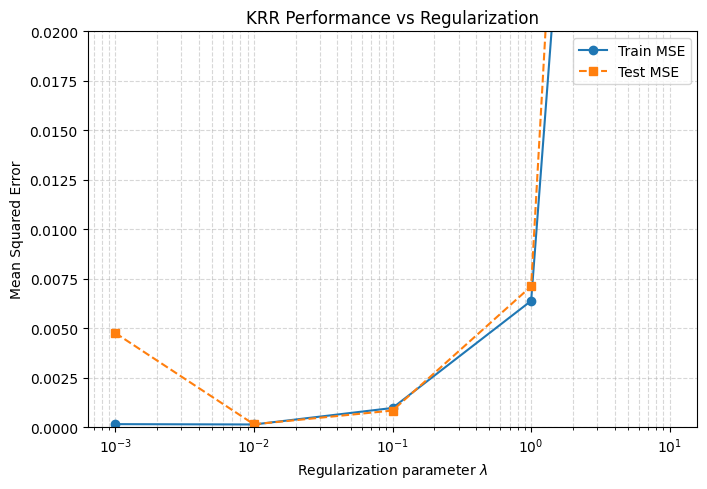

In [2]:
plt.figure(figsize=(7,5))
plt.plot(lambdas, train_mse, "o-", label="Train MSE")
plt.plot(lambdas, test_mse,  "s--", label="Test MSE")

plt.xscale("log")
plt.xlabel(r"Regularization parameter $\lambda$")
plt.ylabel("Mean Squared Error")
plt.title("KRR Performance vs Regularization")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.ylim(0.0, 0.02)
plt.show()

In [3]:
print("Train MSE:", train_mse)
print("Test MSE:", test_mse)

Train MSE: [0.0001503365388738767, 0.0001333983184611556, 0.0009677035702358245, 0.006381079792654692, 0.09892462740662669]
Test MSE: [0.004755999401339554, 0.00014252106512343865, 0.0008377016745619598, 0.007115253219268032, 0.13164125674330235]


## New Kernel, Manual KRR

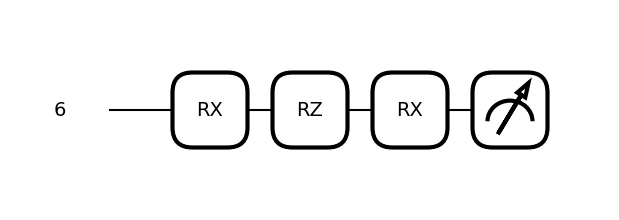

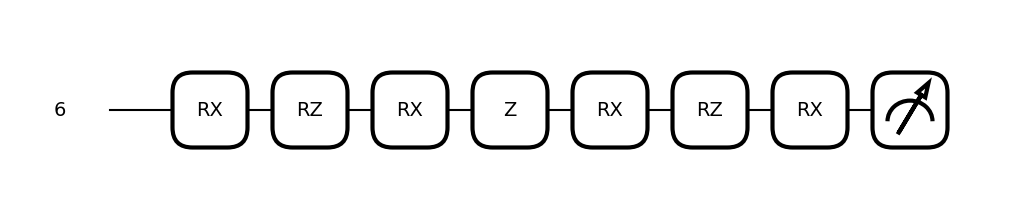

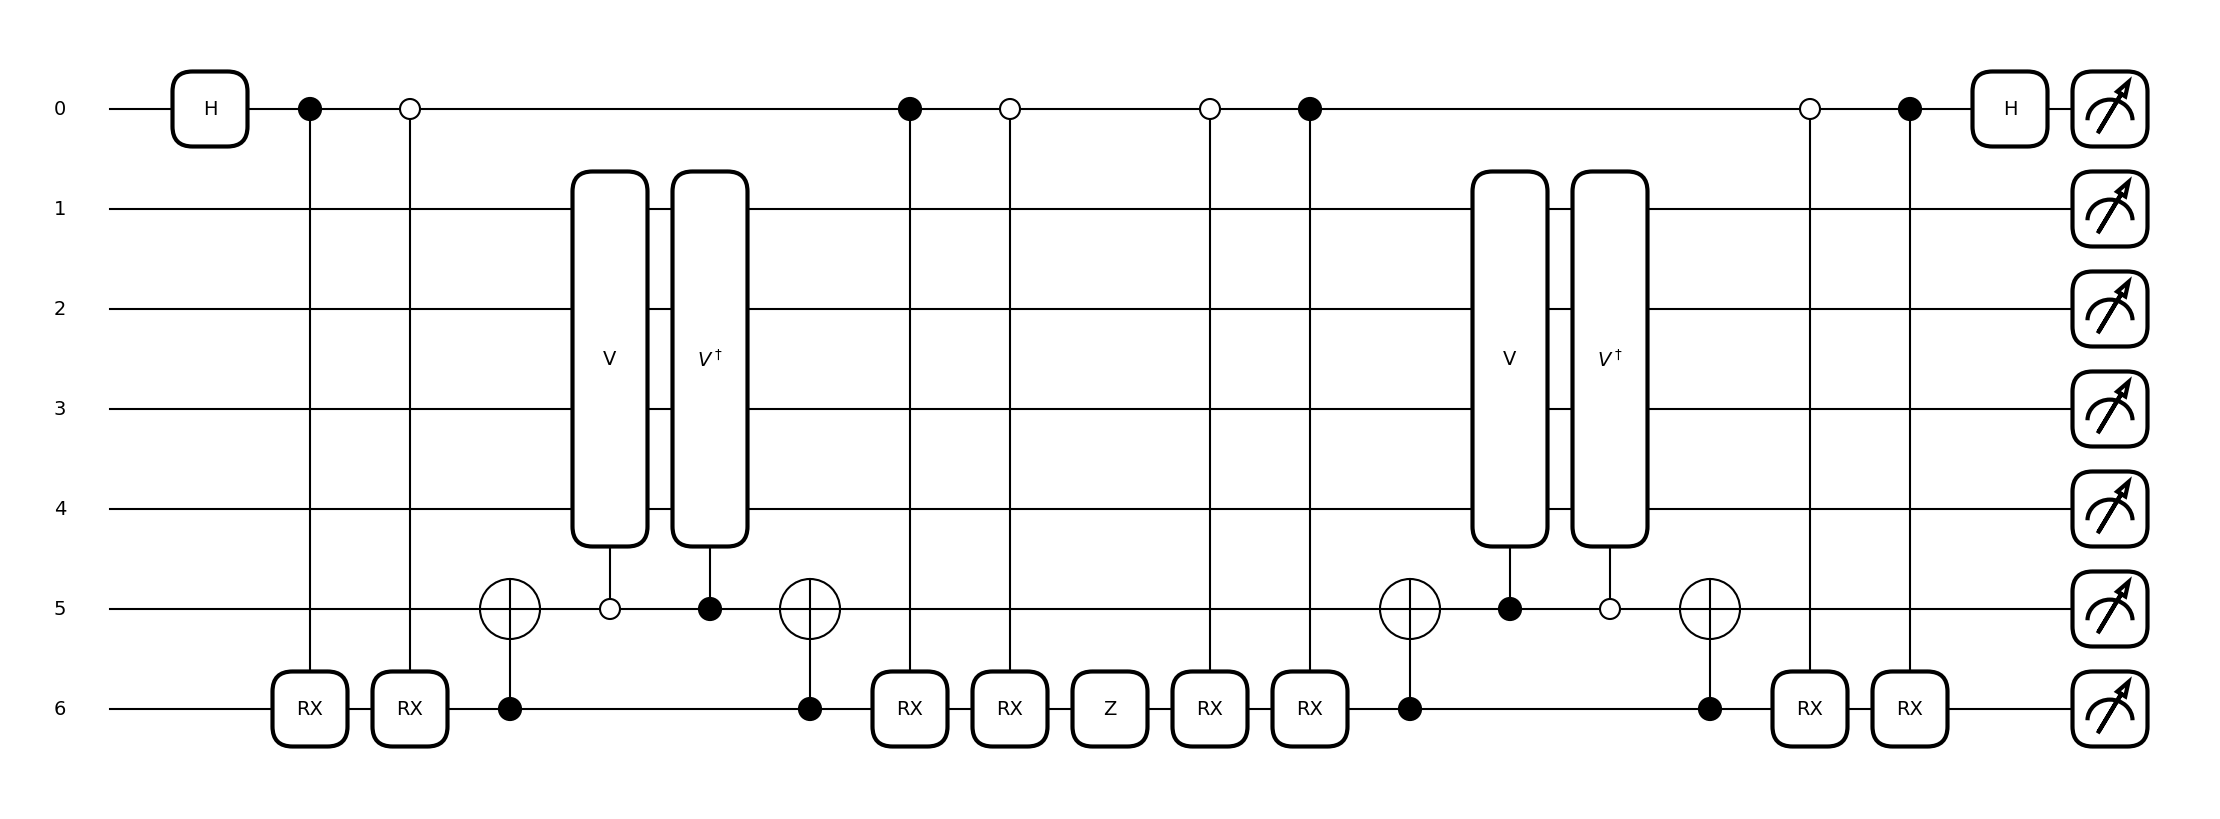

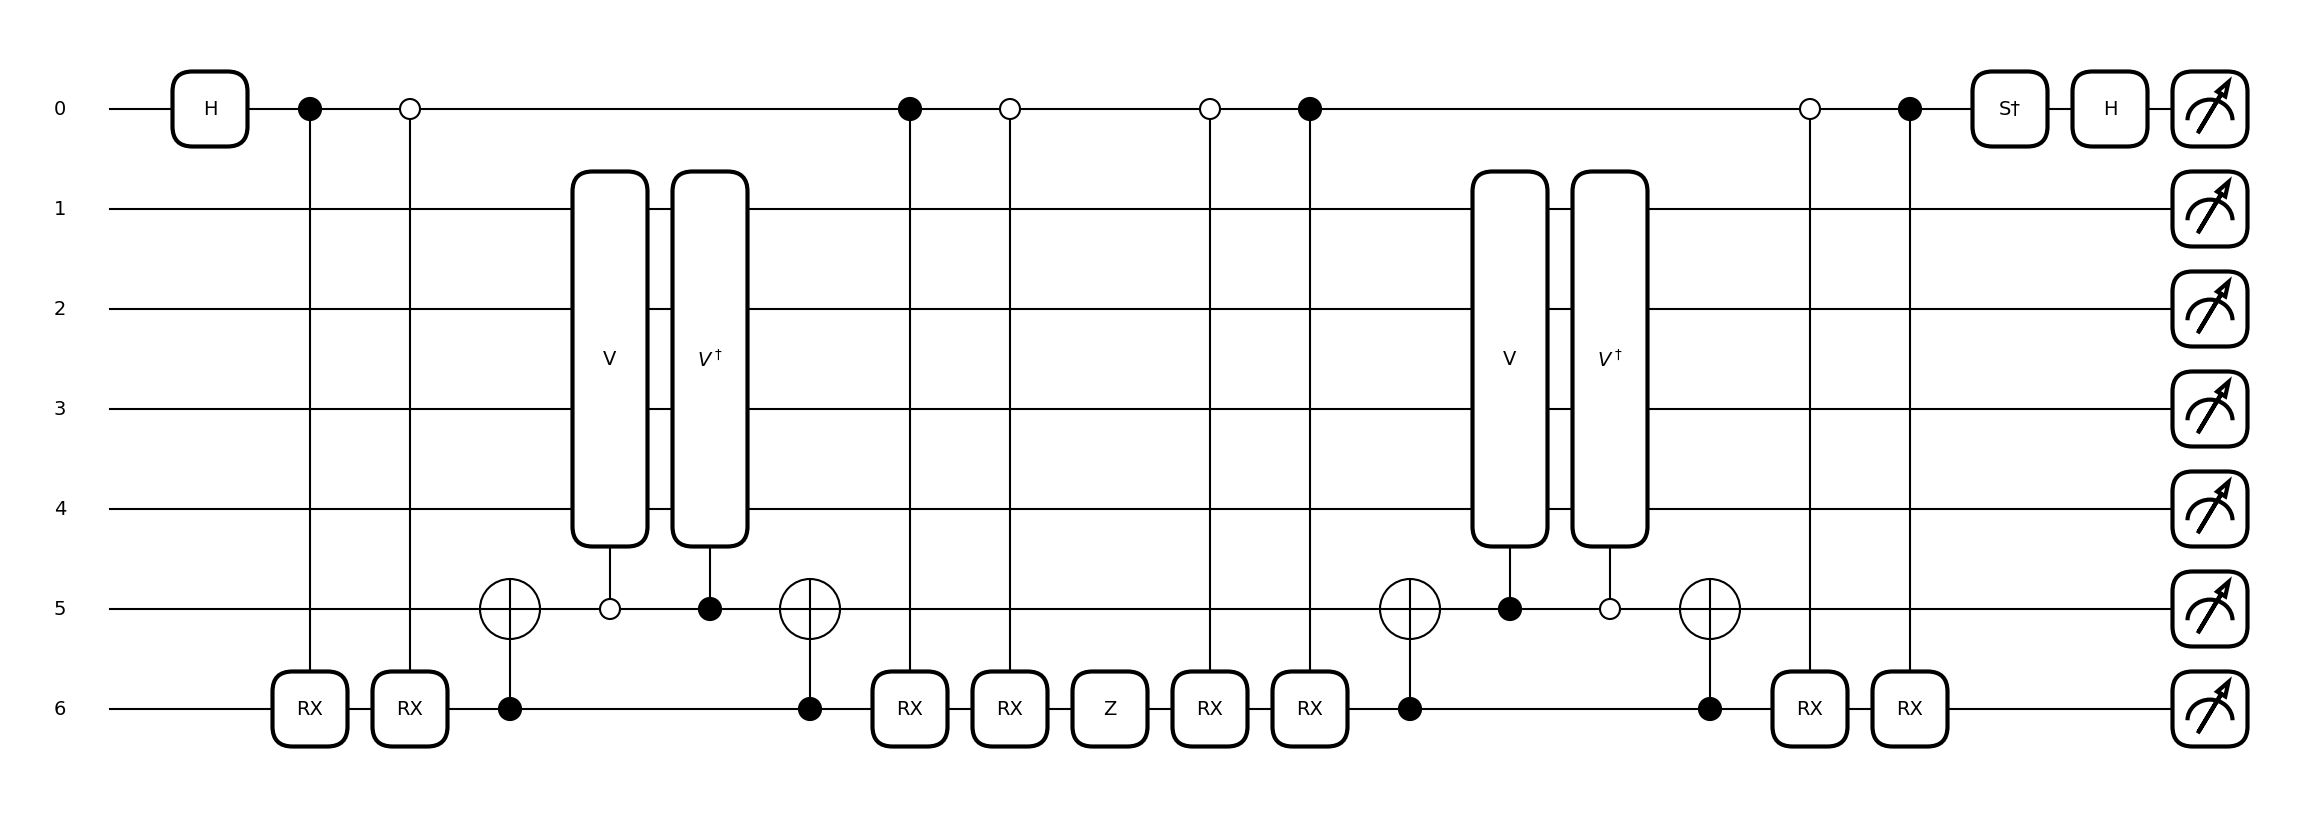

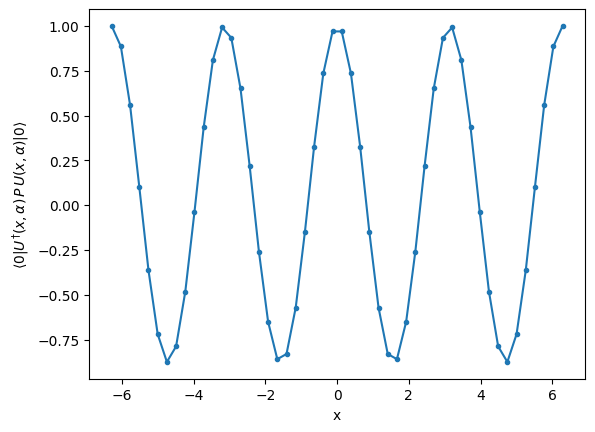

Computing kernel (upper triangle): 100%|██████████| 40/40 [03:18<00:00,  4.97s/it]



Time to compute TRAIN kernel = 198.838 seconds



Computing test kernel: 100%|██████████| 10/10 [01:15<00:00,  7.57s/it]


Time to compute TEST kernel = 75.713 seconds

Time for manual Kernel Ridge Regression fit = 0.057 seconds



ValueError: Complex data not supported
[ 0.97913314+2.81925449e-05j -0.35492264-2.32688666e-04j
  0.97995083+7.22193198e-04j -0.47237332+6.22455422e-04j
  0.10415649+9.60753958e-04j -0.8591046 +6.47705149e-04j
 -0.47313486+5.83899773e-04j  0.10464062-1.06434567e-04j
  0.55232953-1.13195479e-03j  0.21428863+4.96524340e-04j
 -0.03375863-3.73896369e-04j -0.2512351 +4.79377639e-04j
  0.95763049+6.00546488e-04j  0.21565163-7.11666762e-04j
 -0.84244254+9.28521124e-05j  0.98769587-4.06979724e-04j
 -0.70557078-7.24930518e-04j  0.32516998+3.56688286e-04j
 -0.25210538-1.08941560e-04j -0.7060998 -3.02455941e-04j
 -0.55990929+3.39230383e-07j  0.80032098-5.89878488e-04j
  0.92187283-9.48627776e-04j  0.87481246+3.16727114e-04j
 -0.14306971-9.96254319e-05j  0.55304651+1.33943906e-04j
 -0.85895677+1.60525410e-04j  0.64412043-2.31447315e-04j
  0.72740333+1.23996651e-04j -0.03325653+6.16404924e-04j
  0.43055443-5.22490726e-04j  0.32499764-8.02474608e-04j
 -0.84312379+1.48369871e-05j  0.98814962+5.629677

In [7]:
import pennylane as qml
import numpy as np


from tqdm import tqdm
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error, r2_score


SEED = 42
np.random.seed(SEED)


# Wrapper gates for controlled Adders
class V(qml.operation.Operation):
    num_params = 2
    par_domain = "R"
    def __init__(self, value, wires, mod):
        super().__init__(value, mod, wires=wires)

    def decomposition(self):
        # Actual gate: controlled Adder
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]

# Adjoint version
class Vdagger(V):
    def __name__(self):
        return "V†"

    def decomposition(self):
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]
Vdagger.__name__ = r"$V^\dagger$"

dim_x=1
dim_alpha=1
observable_terms=['Z0']

# build_P function
def build_P(observable_terms):
    import pennylane as qml
    P = None
    for term in observable_terms:
        pieces = term.replace('+',' ').split()
        local = None
        for p in pieces:
            op = p[0].upper()
            idx = int(p[1:])
            t = getattr(qml, f'Pauli{op}')(idx)
            local = t if local is None else local @ t
        P = local if P is None else P + local
    return P if P is not None else qml.PauliZ(0)

def build_shifted_P(observable_terms, circ_offset):
            shifted_terms = []
            for term in observable_terms:
                parts = term.replace('+', ' ').split()
                new_parts = []
                for p in parts:
                    op = p[0].upper()
                    idx = int(p[1:])
                    new_parts.append(f"{op}{idx + circ_offset}")
                shifted_terms.append(" ".join(new_parts))
            return build_P(shifted_terms)
        
n_kernel=1; freq_register_sizes={0: 4}; n_freq=4
n_anc=1; n_circ=1; n_total=7
kernel_offset=0; freq_offset=1
anc_offset=5; circ_offset=6
shots = 1000000

dev=qml.device('default.qubit', wires=n_total, shots = shots, seed = SEED)
dev_analytic = qml.device('default.qubit', wires=n_total, shots=None)  # analytic

P_shifted = build_shifted_P(observable_terms, circ_offset=circ_offset)

def U(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)

@qml.qnode(dev_analytic)
def U_return_expval(x, α):
    U(x,α)
    return qml.expval(P_shifted)

@qml.qnode(dev)
def UPU(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)
    # user-provided adjoint (trimmed prefix)
    qml.RX(-x[0], wires=6)
    qml.RZ(-α[0], wires=6)
    qml.RX(-x[0], wires=6)
    return qml.state()

def AuPAu(x, x1, α, part = "real"):
    qml.Hadamard(wires=0)

    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [0])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [1])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)

    # Adjoint – reverse of duplicated U
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [1])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [0])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    
    if part == "imag":
        qml.adjoint(qml.S)(wires = 0)
        
    qml.Hadamard(wires=0)


@qml.qnode(dev)
def AuPAu_sample(x, x1, α, part="real"):
    AuPAu(x, x1, α, part)   # run your circuit
    return qml.sample(wires=range(n_total))


# Example caller
x0=np.zeros(dim_x); x1=np.copy(x0); α0=np.zeros(dim_alpha)
qml.draw_mpl(U_return_expval)(x0, α0); qml.draw_mpl(UPU)(x0, α0); qml.draw_mpl(AuPAu_sample)(x0, x1, α0); qml.draw_mpl(AuPAu_sample)(x0, x1, α0,part = "imag");
plt.show();


# def conditional_Z_kernel(x, x1, α):
#     samples = AuPAu_sample(x, x1, α)

#     # Extract each register
#     kernel = samples[:, kernel_offset]     # wire 0
#     anc = samples[:, anc_offset]           # anc wire
#     circ = samples[:, circ_offset]         # circ wire

#     # Condition: anc=0 and circ=0
#     mask = (anc == 0) & (circ == 0)
#     conditioned = kernel[mask]

#     total = shots
#     kept = conditioned.shape[0]

#     if kept == 0:
#         return {
#             "total_shots": total,
#             "kept_shots": 0,
#             "expectation": None,
#         }

#     # convert bits to Z eigenvalues (+1 for 0, -1 for 1)
#     zvals = 1 - 2*conditioned       # maps 0→+1, 1→−1

#     return {
#         "total_shots": total,
#         "kept_shots": kept,
#         "fraction_kept": kept / total,
#         "expectation": np.mean(zvals),
#     }

def conditional_inner_product(x, x1, α, part="real"):
    samples = AuPAu_sample(x, x1, α, part)

    kernel = samples[:, kernel_offset]
    anc = samples[:, anc_offset]
    circ = samples[:, circ_offset]

    mask = (anc == 0) & (circ == 0)
    conditioned = kernel[mask]

    if conditioned.size == 0:
        return 0.0

    zvals = 1 - 2 * conditioned
    expectation = np.mean(zvals)
    fraction_kept = conditioned.size / shots

    return fraction_kept * expectation


def complex_kernel(x, x1, α):
    re = conditional_inner_product(x, x1, α, part="real")
    im = conditional_inner_product(x, x1, α, part="imag")
    return re + 1j * im


# -------------------------------------------------------
# Generate dataset
# -------------------------------------------------------
def generate_labels(X, α):
    Y = np.array([U_return_expval(x_arr, α) for x_arr in X])
    return Y


# Generated X (list of numpy arrays):
X = [np.array([-6.29]), np.array([-6.033265306122449]), np.array([-5.776530612244898]), np.array([-5.519795918367347]), np.array([-5.263061224489796]), np.array([-5.006326530612245]), np.array([-4.749591836734694]), np.array([-4.492857142857143]), np.array([-4.236122448979591]), np.array([-3.9793877551020405]), np.array([-3.7226530612244897]), np.array([-3.4659183673469385]), np.array([-3.2091836734693873]), np.array([-2.9524489795918365]), np.array([-2.6957142857142853]), np.array([-2.4389795918367345]), np.array([-2.1822448979591833]), np.array([-1.9255102040816325]), np.array([-1.6687755102040809]), np.array([-1.4120408163265301]), np.array([-1.1553061224489793]), np.array([-0.8985714285714277]), np.array([-0.6418367346938769]), np.array([-0.38510204081632615]), np.array([-0.1283673469387745]), np.array([0.12836734693877627]), np.array([0.38510204081632704]), np.array([0.6418367346938778]), np.array([0.8985714285714295]), np.array([1.1553061224489802]), np.array([1.412040816326531]), np.array([1.6687755102040827]), np.array([1.9255102040816334]), np.array([2.182244897959184]), np.array([2.438979591836735]), np.array([2.6957142857142857]), np.array([2.9524489795918383]), np.array([3.209183673469389]), np.array([3.46591836734694]), np.array([3.7226530612244906]), np.array([3.9793877551020413]), np.array([4.236122448979592]), np.array([4.492857142857145]), np.array([4.749591836734695]), np.array([5.006326530612246]), np.array([5.263061224489797]), np.array([5.519795918367348]), np.array([5.7765306122448985]), np.array([6.033265306122451]), np.array([6.29])]
alpha = np.array([0.5])
Y = generate_labels(X,alpha)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, shuffle = True, random_state = SEED)


if dim_x == 1:
    plt.plot(X, Y, ".-")
    plt.xlabel("x")
    plt.ylabel(r"$\langle 0 | U^{\dagger}(x,\alpha)\, P\, U(x,\alpha) | 0 \rangle$")
    plt.show();


# -------------------------------------------------------
# FUNCTION — compute train kernel (precomputed kernel)
# -------------------------------------------------------
# def compute_kernel_matrix_train(X_train, α):
#     n = len(X_train)
#     K = np.zeros((n, n), dtype=complex)

#     for i in tqdm(range(n), desc="Computing train kernel"):
#         for j in range(n):
#             K[i, j] = complex_kernel(X_train[i], X_train[j], α)

#     return K
def compute_kernel_matrix_train(X_train, α):
    n = len(X_train)
    K = np.zeros((n, n), dtype=complex)

    for i in tqdm(range(n), desc="Computing kernel (upper triangle)"):
        for j in range(i, n):
            val = complex_kernel(X_train[i], X_train[j], α)
            K[i, j] = val
            K[j, i] = np.conj(val)

    # Enforce Hermiticity (shot-noise cleanup)
    K = 0.5 * (K + K.conj().T)
    return K



# -------------------------------------------------------
# FUNCTION — compute test kernel (test × train)
# -------------------------------------------------------
def compute_kernel_matrix_test(X_test, X_train, α):
    n_test = len(X_test)
    n_train = len(X_train)
    K = np.zeros((n_test, n_train), dtype=complex)

    for i in tqdm(range(n_test), desc="Computing test kernel"):
        for j in range(n_train):
            K[i, j] = complex_kernel(X_test[i], X_train[j], α)

    return K


# -------------------------------------------------------
# KERNEL COMPUTATION WITH TIMING
# -------------------------------------------------------
start_train = time.time()
K_train = compute_kernel_matrix_train(X_train, alpha)
end_train = time.time()
print(f"\nTime to compute TRAIN kernel = {end_train - start_train:.3f} seconds\n")

start_test = time.time()
K_test = compute_kernel_matrix_test(X_test, X_train, alpha)
end_test = time.time()
print(f"\nTime to compute TEST kernel = {end_test - start_test:.3f} seconds\n")

def manual_krr_fit(K_train, y_train, lam):
    """
    Manual kernel ridge regression fit.
    Works for real or complex kernels.
    """
    n = K_train.shape[0]
    return np.linalg.solve(K_train + lam * np.eye(n), y_train)


def manual_krr_predict(K_test, coeffs):
    """
    Predict using kernel matrix and fitted coefficients.
    """
    return K_test @ coeffs


# -------------------------------------------------------
# MANUAL KERNEL RIDGE REGRESSION
# -------------------------------------------------------
lam = 1e-1

start_krr = time.time()
coeffs = manual_krr_fit(K_train, Y_train, lam)
end_krr = time.time()

print(f"Time for manual Kernel Ridge Regression fit = {end_krr - start_krr:.3f} seconds\n")

Y_train_pred = manual_krr_predict(K_train, coeffs)
Y_test_pred  = manual_krr_predict(K_test, coeffs)
# Y_test_real = Y_test_pred.real


# -------------------------------------------------------
# METRICS
# -------------------------------------------------------
print("Train MSE =", mean_squared_error(Y_train, Y_train_pred))
print("Test MSE  =", mean_squared_error(Y_test, Y_test_pred))

print("Train R2 =", r2_score(Y_train, Y_train_pred))
print("Test R2  =", r2_score(Y_test, Y_test_pred))

# -------------------------------------------------------
# KERNELS
# -------------------------------------------------------
print("")
print("Train Kernel:")
print(K_train)
print("Train-Test Kernel:")
print(K_test)

def show_kernel_heatmap(K, title="Kernel Matrix"):
    plt.figure(figsize=(6, 5))
    plt.imshow(K, aspect='auto')
    plt.colorbar(label='Kernel value')
    plt.title(title)
    plt.xlabel("j index")
    plt.ylabel("i index")
    plt.tight_layout()
    plt.show()

eigvals = np.linalg.eigvalsh(K_train)
print("Min eigenvalue of train kernel:", eigvals.min())
print("Hermiticity error:", np.linalg.norm(K_train - K_train.conj().T))

# show_kernel_heatmap(K_train, "Train Kernel")
# show_kernel_heatmap(K_test, "Test Kernel (test × train)")

# -------------------------------------------------------
# PLOT RESULTS
# -------------------------------------------------------
if dim_x == 1:
    plt.figure(figsize=(10,5))
    plt.scatter([x[0] for x in X_train], Y_train, label="train true", alpha=0.8)
    plt.scatter([x[0] for x in X_train], Y_train_pred, label="train pred", alpha=0.8)

    plt.scatter([x[0] for x in X_test], Y_test, label="test true", alpha=0.8)
    plt.scatter([x[0] for x in X_test], Y_test_pred, label="test pred", alpha=0.8)

    plt.legend()
    plt.xlabel("x")
    plt.ylabel(r"$\langle 0 | U^{\dagger}(x,\alpha)\, P\, U(x,\alpha) | 0 \rangle$")
    plt.title("Kernel Ridge Regression using Quantum Kernel")
    plt.show()





Train MSE = 0.0001011055808600623
Test MSE  = 0.00013735104607703836
Train R2 = 0.9997596710624495
Test R2  = 0.9997566269797967

Train Kernel:
[[0.990814+0.000e+00j 0.275456+5.770e-04j 0.990977-8.380e-04j ...
  0.810828-6.720e-04j 0.387205-4.640e-04j 0.89444 -2.900e-05j]
 [0.275456-5.770e-04j 0.338272+0.000e+00j 0.273902+6.210e-04j ...
  0.290486+1.002e-03j 0.328258+1.270e-04j 0.282934-3.560e-04j]
 [0.990977+8.380e-04j 0.273902-6.210e-04j 0.99082 +0.000e+00j ...
  0.810095+9.950e-04j 0.388352-1.422e-03j 0.894611+1.534e-03j]
 ...
 [0.810828+6.720e-04j 0.290486-1.002e-03j 0.810095-9.950e-04j ...
  0.679296+0.000e+00j 0.374494-3.970e-04j 0.740923-2.930e-04j]
 [0.387205+4.640e-04j 0.328258-1.270e-04j 0.388352+1.422e-03j ...
  0.374494+3.970e-04j 0.338043+0.000e+00j 0.378911-2.690e-04j]
 [0.89444 +2.900e-05j 0.282934+3.560e-04j 0.894611-1.534e-03j ...
  0.740923+2.930e-04j 0.378911+2.690e-04j 0.812381+0.000e+00j]]
Train-Test Kernel:
[[0.960266-2.420e-03j 0.276455+1.077e-03j 0.960386+3.470e

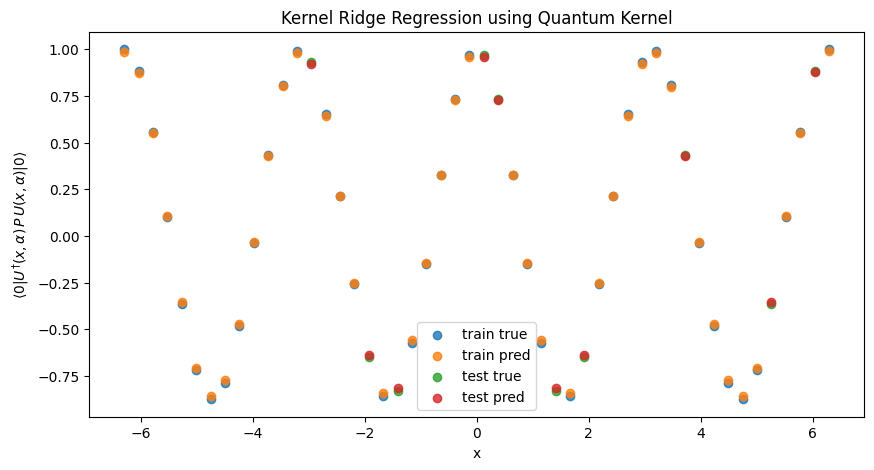

In [8]:

def manual_krr_predict(K_test, coeffs):
    """
    Predict using kernel matrix and fitted coefficients.
    """
    return (K_test @ coeffs).real

Y_train_pred = manual_krr_predict(K_train, coeffs)
Y_test_pred  = manual_krr_predict(K_test, coeffs)
# Y_test_real = Y_test_pred.real


# -------------------------------------------------------
# METRICS
# -------------------------------------------------------
print("Train MSE =", mean_squared_error(Y_train, Y_train_pred))
print("Test MSE  =", mean_squared_error(Y_test, Y_test_pred))

print("Train R2 =", r2_score(Y_train, Y_train_pred))
print("Test R2  =", r2_score(Y_test, Y_test_pred))

# -------------------------------------------------------
# KERNELS
# -------------------------------------------------------
print("")
print("Train Kernel:")
print(K_train)
print("Train-Test Kernel:")
print(K_test)

def show_kernel_heatmap(K, title="Kernel Matrix"):
    plt.figure(figsize=(6, 5))
    plt.imshow(K, aspect='auto')
    plt.colorbar(label='Kernel value')
    plt.title(title)
    plt.xlabel("j index")
    plt.ylabel("i index")
    plt.tight_layout()
    plt.show()

eigvals = np.linalg.eigvalsh(K_train)
print("Min eigenvalue of train kernel:", eigvals.min())
print("Hermiticity error:", np.linalg.norm(K_train - K_train.conj().T))

# show_kernel_heatmap(K_train, "Train Kernel")
# show_kernel_heatmap(K_test, "Test Kernel (test × train)")

# -------------------------------------------------------
# PLOT RESULTS
# -------------------------------------------------------
if dim_x == 1:
    plt.figure(figsize=(10,5))
    plt.scatter([x[0] for x in X_train], Y_train, label="train true", alpha=0.8)
    plt.scatter([x[0] for x in X_train], Y_train_pred, label="train pred", alpha=0.8)

    plt.scatter([x[0] for x in X_test], Y_test, label="test true", alpha=0.8)
    plt.scatter([x[0] for x in X_test], Y_test_pred, label="test pred", alpha=0.8)

    plt.legend()
    plt.xlabel("x")
    plt.ylabel(r"$\langle 0 | U^{\dagger}(x,\alpha)\, P\, U(x,\alpha) | 0 \rangle$")
    plt.title("Kernel Ridge Regression using Quantum Kernel")
    plt.show()



## New Kernel, Manual KRR, Vary Lambda, prediction is real part

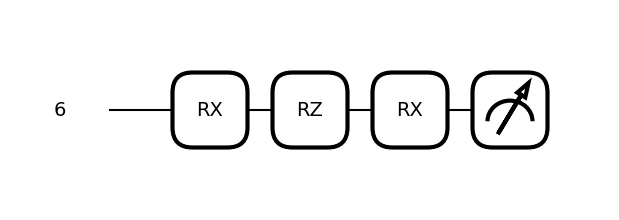

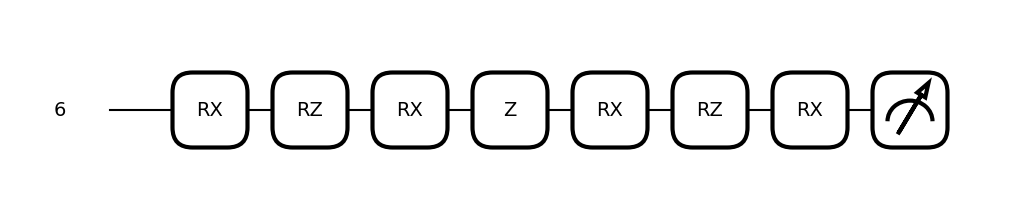

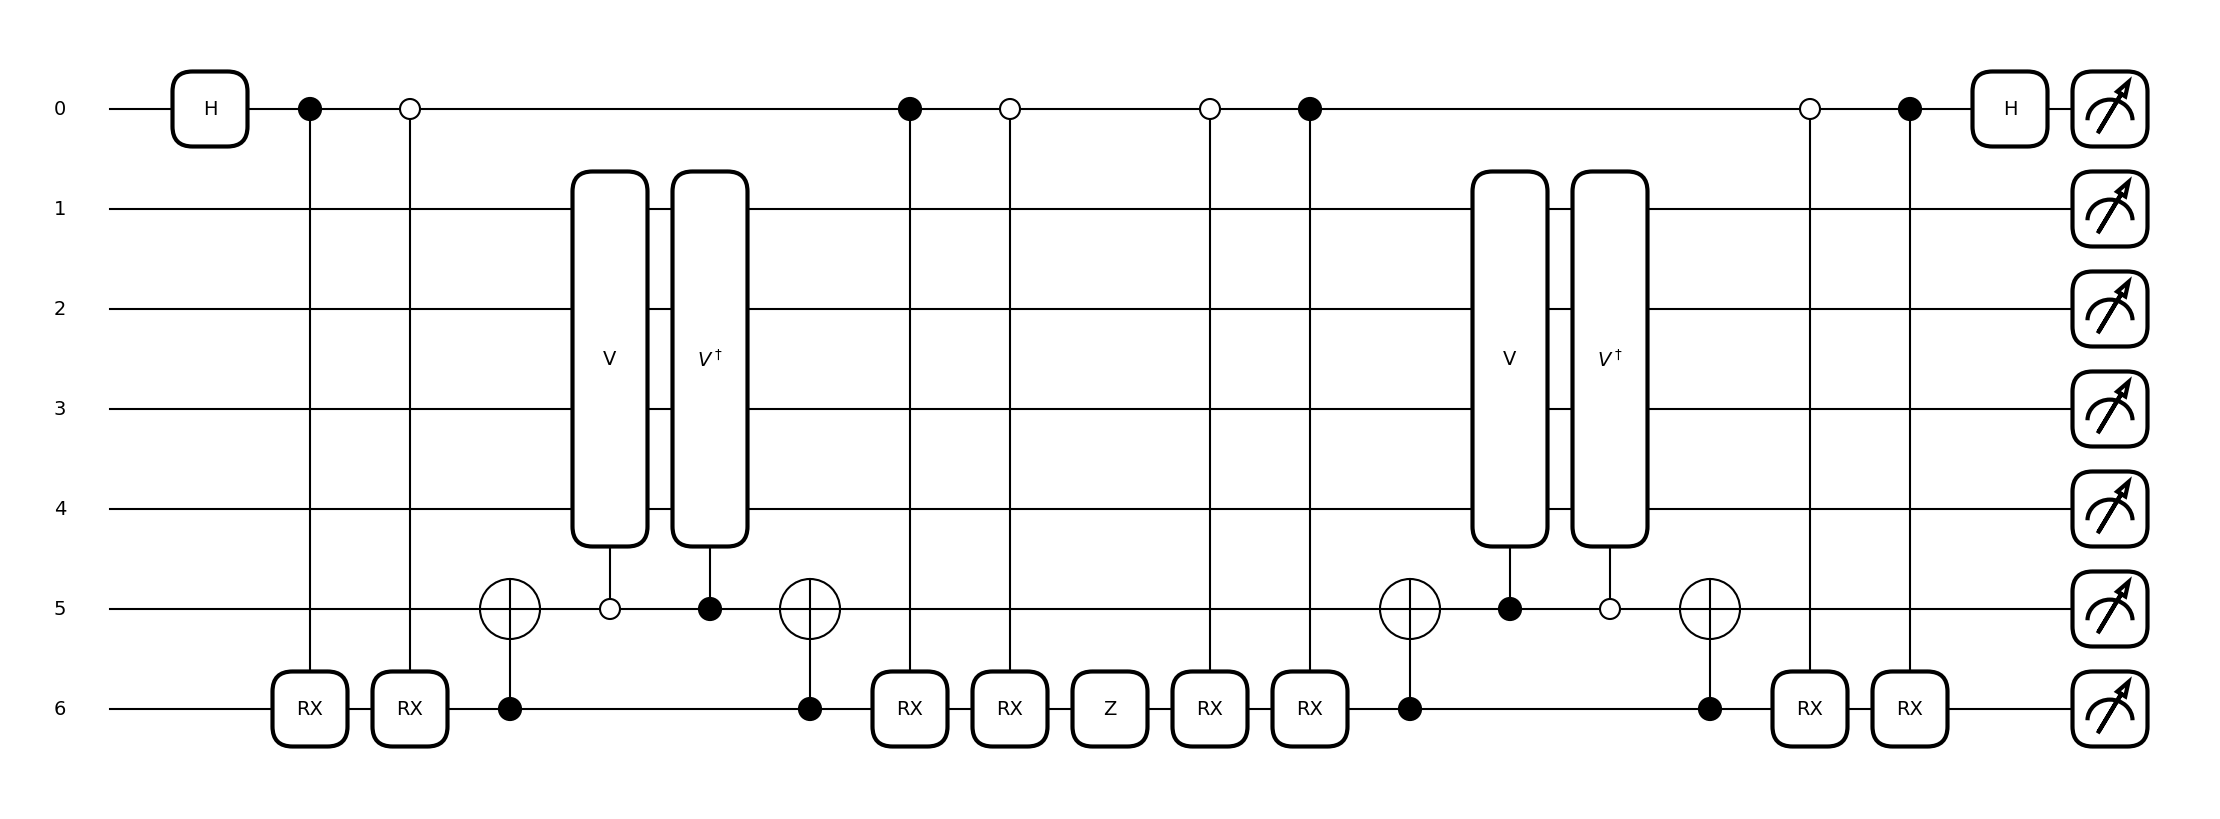

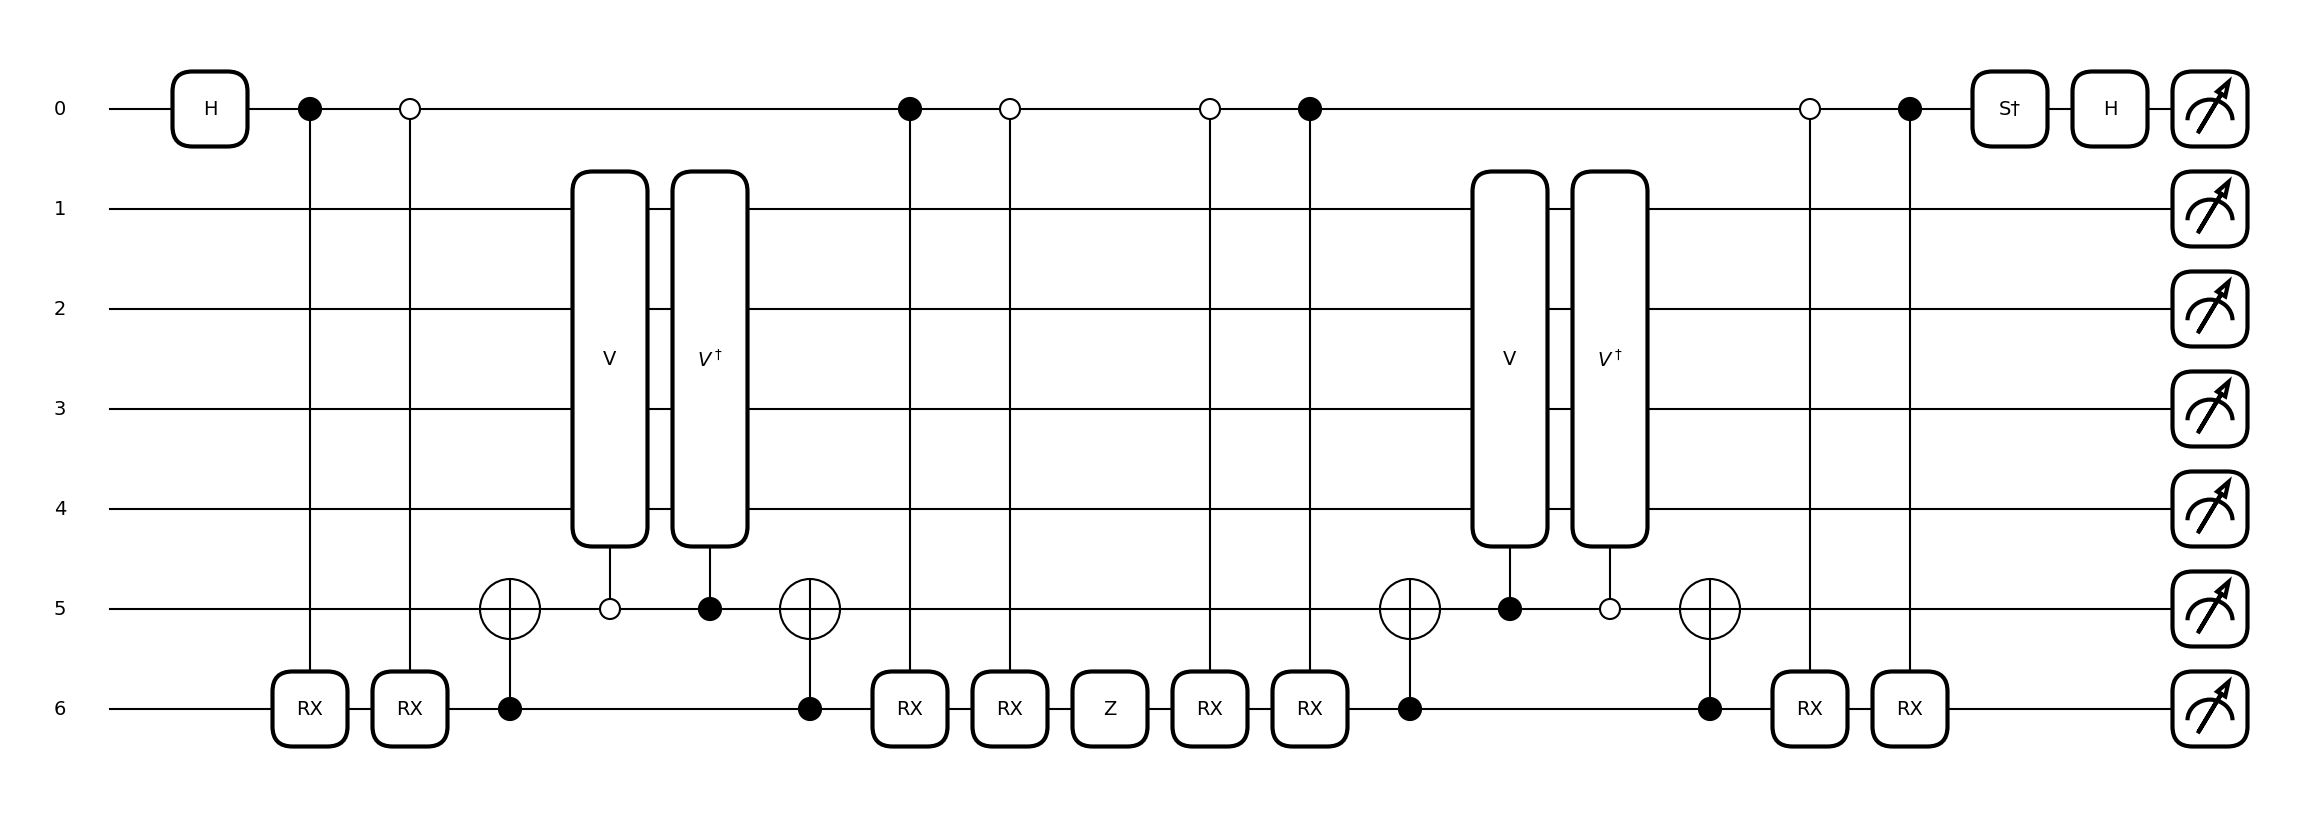

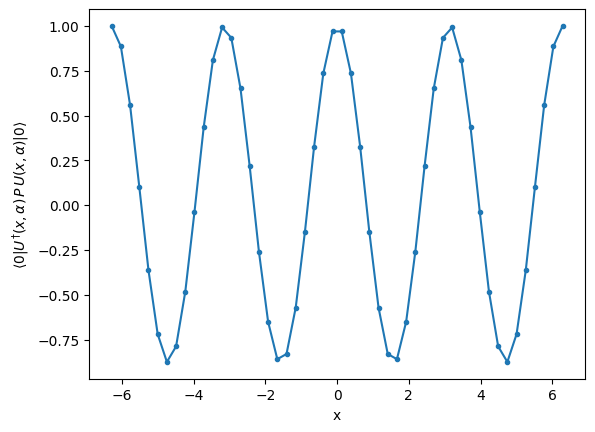

Computing kernel (upper triangle): 100%|██████████| 40/40 [05:45<00:00,  8.63s/it]



Time to compute TRAIN kernel = 345.333 seconds



Computing test kernel: 100%|██████████| 10/10 [04:20<00:00, 26.03s/it]



Time to compute TEST kernel = 260.303 seconds



Sweeping lambda (KRR): 100%|██████████| 5/5 [00:00<00:00, 42.41λ/s]



Train Kernel:
[[0.990814+0.000e+00j 0.275456+5.770e-04j 0.990977-8.380e-04j ...
  0.810828-6.720e-04j 0.387205-4.640e-04j 0.89444 -2.900e-05j]
 [0.275456-5.770e-04j 0.338272+0.000e+00j 0.273902+6.210e-04j ...
  0.290486+1.002e-03j 0.328258+1.270e-04j 0.282934-3.560e-04j]
 [0.990977+8.380e-04j 0.273902-6.210e-04j 0.99082 +0.000e+00j ...
  0.810095+9.950e-04j 0.388352-1.422e-03j 0.894611+1.534e-03j]
 ...
 [0.810828+6.720e-04j 0.290486-1.002e-03j 0.810095-9.950e-04j ...
  0.679296+0.000e+00j 0.374494-3.970e-04j 0.740923-2.930e-04j]
 [0.387205+4.640e-04j 0.328258-1.270e-04j 0.388352+1.422e-03j ...
  0.374494+3.970e-04j 0.338043+0.000e+00j 0.378911-2.690e-04j]
 [0.89444 +2.900e-05j 0.282934+3.560e-04j 0.894611-1.534e-03j ...
  0.740923+2.930e-04j 0.378911+2.690e-04j 0.812381+0.000e+00j]]
Train-Test Kernel:
[[0.960266-2.420e-03j 0.276455+1.077e-03j 0.960386+3.470e-04j
  0.217118+1.010e-04j 0.511893-2.690e-04j 0.019696-5.030e-04j
  0.218039+5.470e-04j 0.51238 -6.710e-04j 0.742015-1.722e-03j


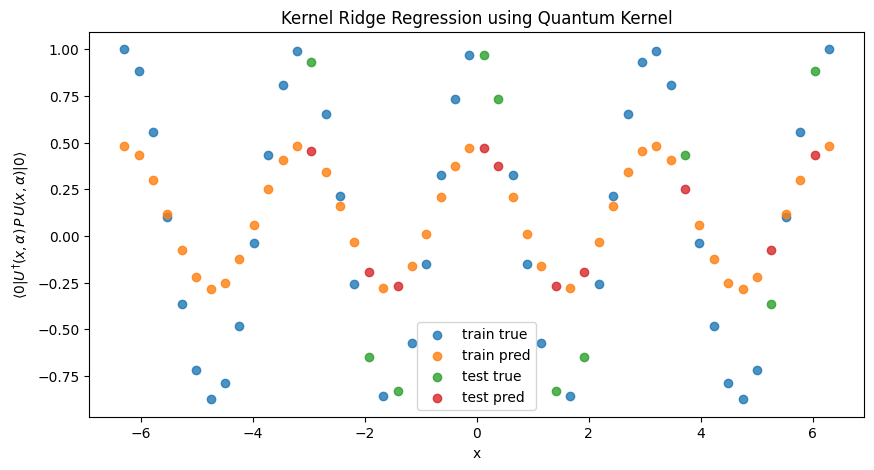

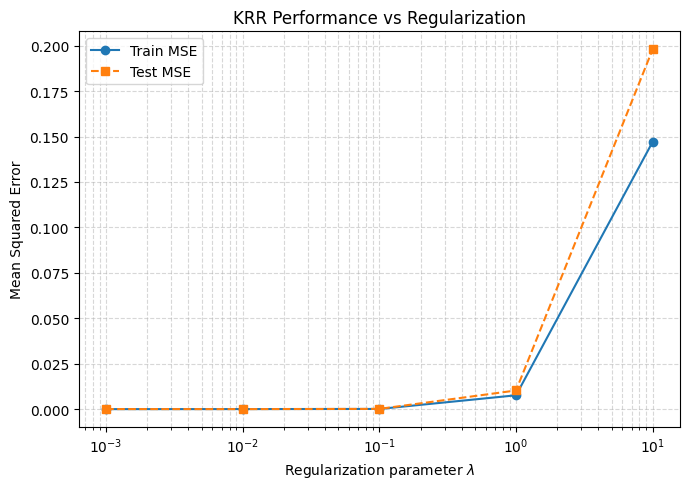

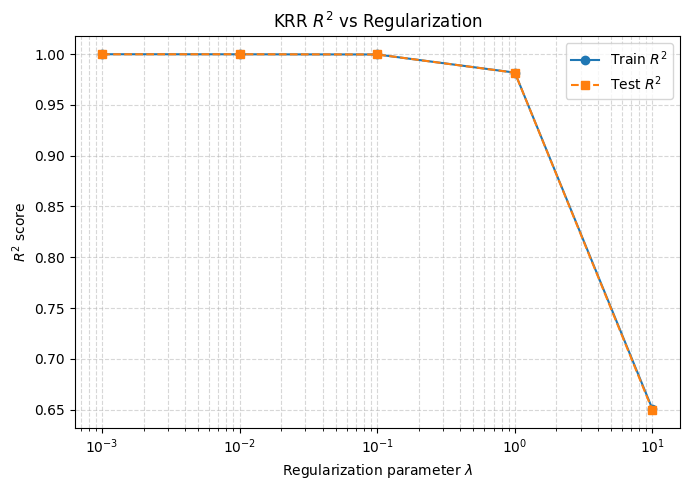

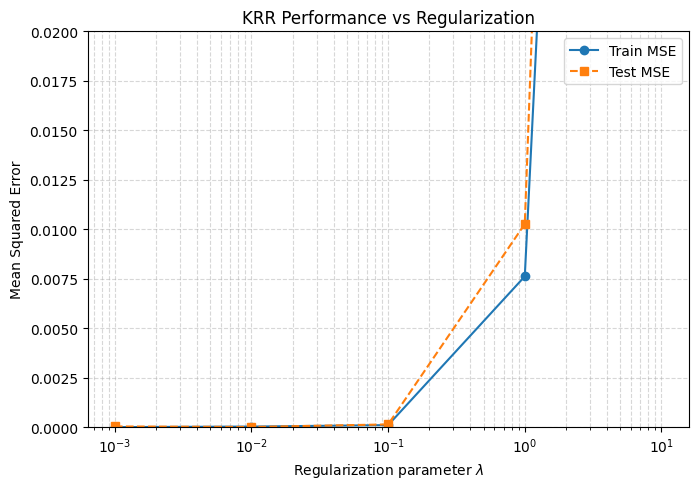

Train MSE: [6.235442920747619e-07, 2.816612041440289e-05, 0.0001011055808600623, 0.007616955319029148, 0.14710238788268531]
Test MSE: [3.4553282657635924e-05, 6.0317112749509014e-06, 0.00013735104607703836, 0.010263195745505766, 0.1979773501066085]


In [5]:
import pennylane as qml
import numpy as np


from tqdm import tqdm
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error, r2_score


SEED = 42
np.random.seed(SEED)


# Wrapper gates for controlled Adders
class V(qml.operation.Operation):
    num_params = 2
    par_domain = "R"
    def __init__(self, value, wires, mod):
        super().__init__(value, mod, wires=wires)

    def decomposition(self):
        # Actual gate: controlled Adder
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]

# Adjoint version
class Vdagger(V):
    def __name__(self):
        return "V†"

    def decomposition(self):
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]
Vdagger.__name__ = r"$V^\dagger$"

dim_x=1
dim_alpha=1
observable_terms=['Z0']

# build_P function
def build_P(observable_terms):
    import pennylane as qml
    P = None
    for term in observable_terms:
        pieces = term.replace('+',' ').split()
        local = None
        for p in pieces:
            op = p[0].upper()
            idx = int(p[1:])
            t = getattr(qml, f'Pauli{op}')(idx)
            local = t if local is None else local @ t
        P = local if P is None else P + local
    return P if P is not None else qml.PauliZ(0)

def build_shifted_P(observable_terms, circ_offset):
            shifted_terms = []
            for term in observable_terms:
                parts = term.replace('+', ' ').split()
                new_parts = []
                for p in parts:
                    op = p[0].upper()
                    idx = int(p[1:])
                    new_parts.append(f"{op}{idx + circ_offset}")
                shifted_terms.append(" ".join(new_parts))
            return build_P(shifted_terms)
        
n_kernel=1; freq_register_sizes={0: 4}; n_freq=4
n_anc=1; n_circ=1; n_total=7
kernel_offset=0; freq_offset=1
anc_offset=5; circ_offset=6
shots = 1000000

dev=qml.device('default.qubit', wires=n_total, shots = shots, seed = SEED)
dev_analytic = qml.device('default.qubit', wires=n_total, shots=None)  # analytic

P_shifted = build_shifted_P(observable_terms, circ_offset=circ_offset)

def U(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)

@qml.qnode(dev_analytic)
def U_return_expval(x, α):
    U(x,α)
    return qml.expval(P_shifted)

@qml.qnode(dev)
def UPU(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)
    # user-provided adjoint (trimmed prefix)
    qml.RX(-x[0], wires=6)
    qml.RZ(-α[0], wires=6)
    qml.RX(-x[0], wires=6)
    return qml.state()

def AuPAu(x, x1, α, part = "real"):
    qml.Hadamard(wires=0)

    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [0])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [1])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)

    # Adjoint – reverse of duplicated U
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [1])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [0])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    
    if part == "imag":
        qml.adjoint(qml.S)(wires = 0)
        
    qml.Hadamard(wires=0)


@qml.qnode(dev)
def AuPAu_sample(x, x1, α, part="real"):
    AuPAu(x, x1, α, part)   # run your circuit
    return qml.sample(wires=range(n_total))


# Example caller
x0=np.zeros(dim_x); x1=np.copy(x0); α0=np.zeros(dim_alpha)
qml.draw_mpl(U_return_expval)(x0, α0); qml.draw_mpl(UPU)(x0, α0); qml.draw_mpl(AuPAu_sample)(x0, x1, α0); qml.draw_mpl(AuPAu_sample)(x0, x1, α0,part = "imag");
plt.show();


# def conditional_Z_kernel(x, x1, α):
#     samples = AuPAu_sample(x, x1, α)

#     # Extract each register
#     kernel = samples[:, kernel_offset]     # wire 0
#     anc = samples[:, anc_offset]           # anc wire
#     circ = samples[:, circ_offset]         # circ wire

#     # Condition: anc=0 and circ=0
#     mask = (anc == 0) & (circ == 0)
#     conditioned = kernel[mask]

#     total = shots
#     kept = conditioned.shape[0]

#     if kept == 0:
#         return {
#             "total_shots": total,
#             "kept_shots": 0,
#             "expectation": None,
#         }

#     # convert bits to Z eigenvalues (+1 for 0, -1 for 1)
#     zvals = 1 - 2*conditioned       # maps 0→+1, 1→−1

#     return {
#         "total_shots": total,
#         "kept_shots": kept,
#         "fraction_kept": kept / total,
#         "expectation": np.mean(zvals),
#     }

def conditional_inner_product(x, x1, α, part="real"):
    samples = AuPAu_sample(x, x1, α, part)

    kernel = samples[:, kernel_offset]
    anc = samples[:, anc_offset]
    circ = samples[:, circ_offset]

    mask = (anc == 0) & (circ == 0)
    conditioned = kernel[mask]

    if conditioned.size == 0:
        return 0.0

    zvals = 1 - 2 * conditioned
    expectation = np.mean(zvals)
    fraction_kept = conditioned.size / shots

    return fraction_kept * expectation


def complex_kernel(x, x1, α):
    re = conditional_inner_product(x, x1, α, part="real")
    im = conditional_inner_product(x, x1, α, part="imag")
    return re + 1j * im


# -------------------------------------------------------
# Generate dataset
# -------------------------------------------------------
def generate_labels(X, α):
    Y = np.array([U_return_expval(x_arr, α) for x_arr in X])
    return Y


# Generated X (list of numpy arrays):
X = [np.array([-6.29]), np.array([-6.033265306122449]), np.array([-5.776530612244898]), np.array([-5.519795918367347]), np.array([-5.263061224489796]), np.array([-5.006326530612245]), np.array([-4.749591836734694]), np.array([-4.492857142857143]), np.array([-4.236122448979591]), np.array([-3.9793877551020405]), np.array([-3.7226530612244897]), np.array([-3.4659183673469385]), np.array([-3.2091836734693873]), np.array([-2.9524489795918365]), np.array([-2.6957142857142853]), np.array([-2.4389795918367345]), np.array([-2.1822448979591833]), np.array([-1.9255102040816325]), np.array([-1.6687755102040809]), np.array([-1.4120408163265301]), np.array([-1.1553061224489793]), np.array([-0.8985714285714277]), np.array([-0.6418367346938769]), np.array([-0.38510204081632615]), np.array([-0.1283673469387745]), np.array([0.12836734693877627]), np.array([0.38510204081632704]), np.array([0.6418367346938778]), np.array([0.8985714285714295]), np.array([1.1553061224489802]), np.array([1.412040816326531]), np.array([1.6687755102040827]), np.array([1.9255102040816334]), np.array([2.182244897959184]), np.array([2.438979591836735]), np.array([2.6957142857142857]), np.array([2.9524489795918383]), np.array([3.209183673469389]), np.array([3.46591836734694]), np.array([3.7226530612244906]), np.array([3.9793877551020413]), np.array([4.236122448979592]), np.array([4.492857142857145]), np.array([4.749591836734695]), np.array([5.006326530612246]), np.array([5.263061224489797]), np.array([5.519795918367348]), np.array([5.7765306122448985]), np.array([6.033265306122451]), np.array([6.29])]
alpha = np.array([0.5])
Y = generate_labels(X,alpha)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, shuffle = True, random_state = SEED)


if dim_x == 1:
    plt.plot(X, Y, ".-")
    plt.xlabel("x")
    plt.ylabel(r"$\langle 0 | U^{\dagger}(x,\alpha)\, P\, U(x,\alpha) | 0 \rangle$")
    plt.show();


# -------------------------------------------------------
# FUNCTION — compute train kernel (precomputed kernel)
# -------------------------------------------------------
# def compute_kernel_matrix_train(X_train, α):
#     n = len(X_train)
#     K = np.zeros((n, n), dtype=complex)

#     for i in tqdm(range(n), desc="Computing train kernel"):
#         for j in range(n):
#             K[i, j] = complex_kernel(X_train[i], X_train[j], α)

#     return K
def compute_kernel_matrix_train(X_train, α):
    n = len(X_train)
    K = np.zeros((n, n), dtype=complex)

    for i in tqdm(range(n), desc="Computing kernel (upper triangle)"):
        for j in range(i, n):
            val = complex_kernel(X_train[i], X_train[j], α)
            K[i, j] = val
            K[j, i] = np.conj(val)

    # Enforce Hermiticity (shot-noise cleanup)
    K = 0.5 * (K + K.conj().T)
    return K



# -------------------------------------------------------
# FUNCTION — compute test kernel (test × train)
# -------------------------------------------------------
def compute_kernel_matrix_test(X_test, X_train, α):
    n_test = len(X_test)
    n_train = len(X_train)
    K = np.zeros((n_test, n_train), dtype=complex)

    for i in tqdm(range(n_test), desc="Computing test kernel"):
        for j in range(n_train):
            K[i, j] = complex_kernel(X_test[i], X_train[j], α)

    return K


# -------------------------------------------------------
# KERNEL COMPUTATION WITH TIMING
# -------------------------------------------------------
start_train = time.time()
K_train = compute_kernel_matrix_train(X_train, alpha)
end_train = time.time()
print(f"\nTime to compute TRAIN kernel = {end_train - start_train:.3f} seconds\n")

start_test = time.time()
K_test = compute_kernel_matrix_test(X_test, X_train, alpha)
end_test = time.time()
print(f"\nTime to compute TEST kernel = {end_test - start_test:.3f} seconds\n")

def manual_krr_fit(K_train, y_train, lam):
    """
    Manual kernel ridge regression fit.
    Works for real or complex kernels.
    """
    n = K_train.shape[0]
    return np.linalg.solve(K_train + lam * np.eye(n), y_train)


def manual_krr_predict(K_test, coeffs):
    """
    Predict using kernel matrix and fitted coefficients.
    """
    return (K_test @ coeffs).real


# -------------------------------------------------------
# MANUAL KERNEL RIDGE REGRESSION
# -------------------------------------------------------
lambdas = [1e-3, 1e-2, 1e-1, 1, 1e1]

train_mse = []
test_mse = []
train_r2 = []
test_r2 = []

for lam in tqdm(lambdas, desc="Sweeping lambda (KRR)",unit="λ"):
    # Fit
    coeffs = manual_krr_fit(K_train, Y_train, lam)

    # Predict
    Y_train_pred = manual_krr_predict(K_train, coeffs)
    Y_test_pred  = manual_krr_predict(K_test, coeffs)

    # Metrics
    train_mse.append(mean_squared_error(Y_train, Y_train_pred))
    test_mse.append(mean_squared_error(Y_test, Y_test_pred))

    train_r2.append(r2_score(Y_train, Y_train_pred))
    test_r2.append(r2_score(Y_test, Y_test_pred))

# -------------------------------------------------------
# KERNELS
# -------------------------------------------------------
print("")
print("Train Kernel:")
print(K_train)
print("Train-Test Kernel:")
print(K_test)

def show_kernel_heatmap(K, title="Kernel Matrix"):
    plt.figure(figsize=(6, 5))
    plt.imshow(K, aspect='auto')
    plt.colorbar(label='Kernel value')
    plt.title(title)
    plt.xlabel("j index")
    plt.ylabel("i index")
    plt.tight_layout()
    plt.show()

eigvals = np.linalg.eigvalsh(K_train)
print("Min eigenvalue of train kernel:", eigvals.min())
print("Hermiticity error:", np.linalg.norm(K_train - K_train.conj().T))

# show_kernel_heatmap(K_train, "Train Kernel")
# show_kernel_heatmap(K_test, "Test Kernel (test × train)")

# -------------------------------------------------------
# PLOT RESULTS
# -------------------------------------------------------
if dim_x == 1:
    plt.figure(figsize=(10,5))
    plt.scatter([x[0] for x in X_train], Y_train, label="train true", alpha=0.8)
    plt.scatter([x[0] for x in X_train], Y_train_pred, label="train pred", alpha=0.8)

    plt.scatter([x[0] for x in X_test], Y_test, label="test true", alpha=0.8)
    plt.scatter([x[0] for x in X_test], Y_test_pred, label="test pred", alpha=0.8)

    plt.legend()
    plt.xlabel("x")
    plt.ylabel(r"$\langle 0 | U^{\dagger}(x,\alpha)\, P\, U(x,\alpha) | 0 \rangle$")
    plt.title("Kernel Ridge Regression using Quantum Kernel")
    plt.show()

plt.figure(figsize=(7,5))
plt.plot(lambdas, train_mse, "o-", label="Train MSE")
plt.plot(lambdas, test_mse,  "s--", label="Test MSE")

plt.xscale("log")
plt.xlabel(r"Regularization parameter $\lambda$")
plt.ylabel("Mean Squared Error")
plt.title("KRR Performance vs Regularization")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
plt.plot(lambdas, train_r2, "o-", label="Train $R^2$")
plt.plot(lambdas, test_r2,  "s--", label="Test $R^2$")

plt.xscale("log")
plt.xlabel(r"Regularization parameter $\lambda$")
plt.ylabel(r"$R^2$ score")
plt.title("KRR $R^2$ vs Regularization")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
plt.plot(lambdas, train_mse, "o-", label="Train MSE")
plt.plot(lambdas, test_mse,  "s--", label="Test MSE")

plt.xscale("log")
plt.xlabel(r"Regularization parameter $\lambda$")
plt.ylabel("Mean Squared Error")
plt.title("KRR Performance vs Regularization")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.ylim(0.0, 0.02)
plt.show()

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)

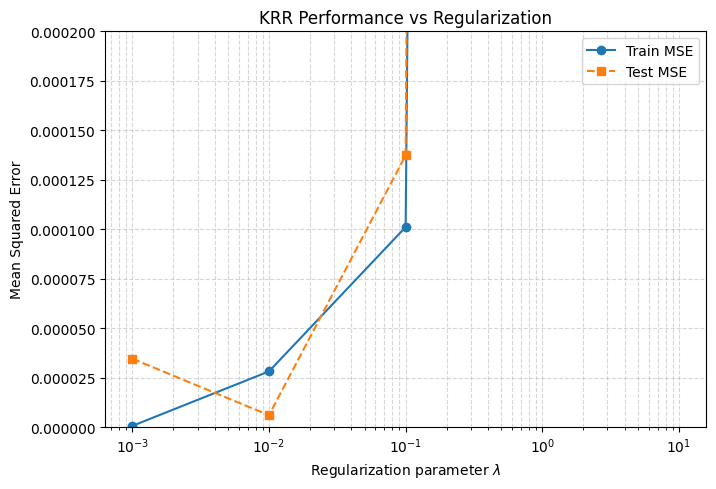

In [7]:
plt.figure(figsize=(7,5))
plt.plot(lambdas, train_mse, "o-", label="Train MSE")
plt.plot(lambdas, test_mse,  "s--", label="Test MSE")

plt.xscale("log")
plt.xlabel(r"Regularization parameter $\lambda$")
plt.ylabel("Mean Squared Error")
plt.title("KRR Performance vs Regularization")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.ylim(0.0, 0.0002)
plt.show()

## New Kernel, Manual KRR, Vary lambda, prediction is real part, avg over 10 seeds

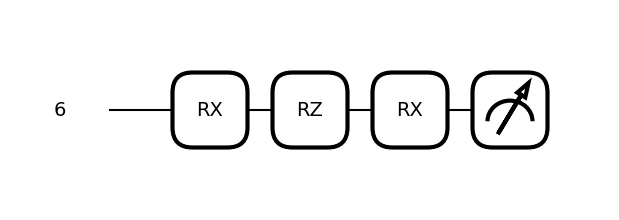

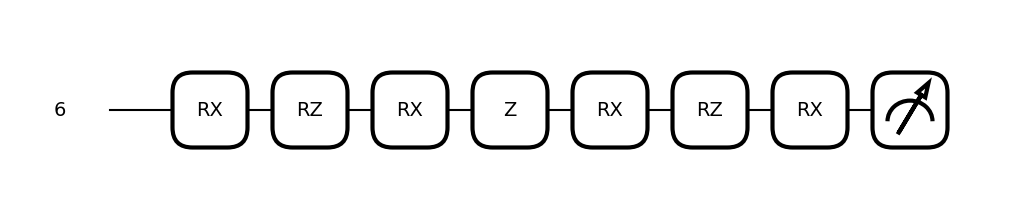

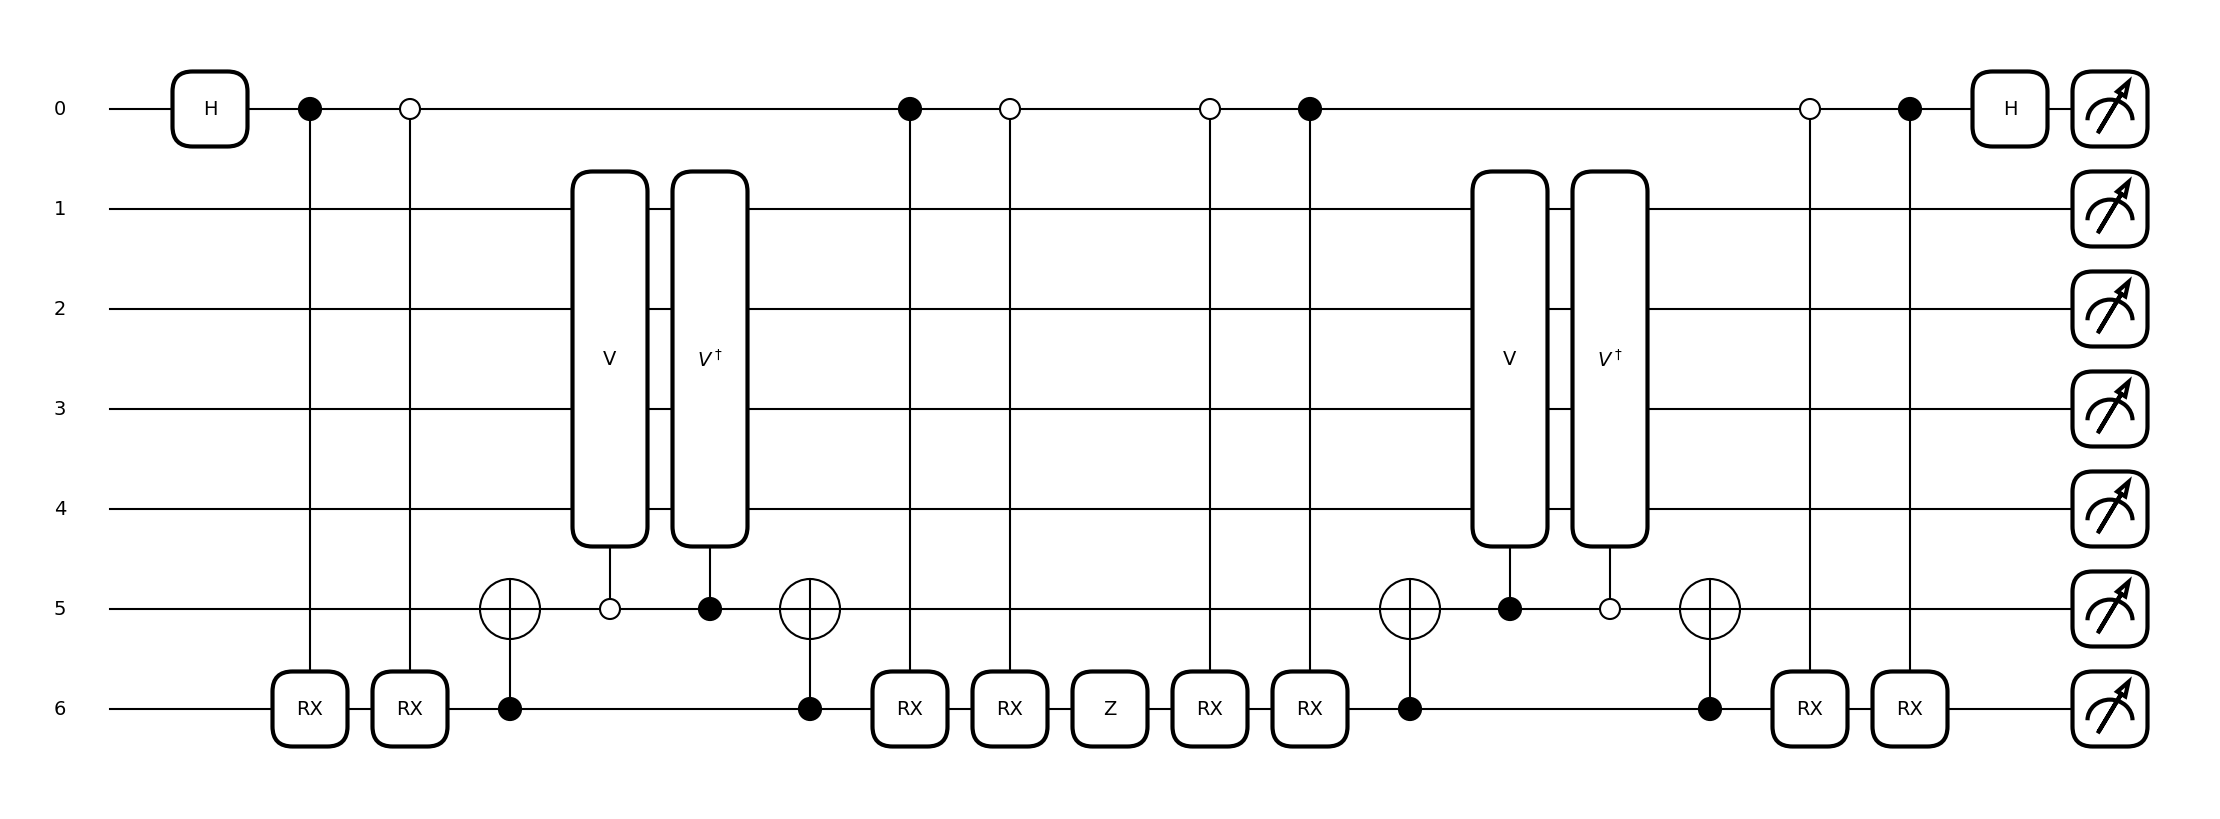

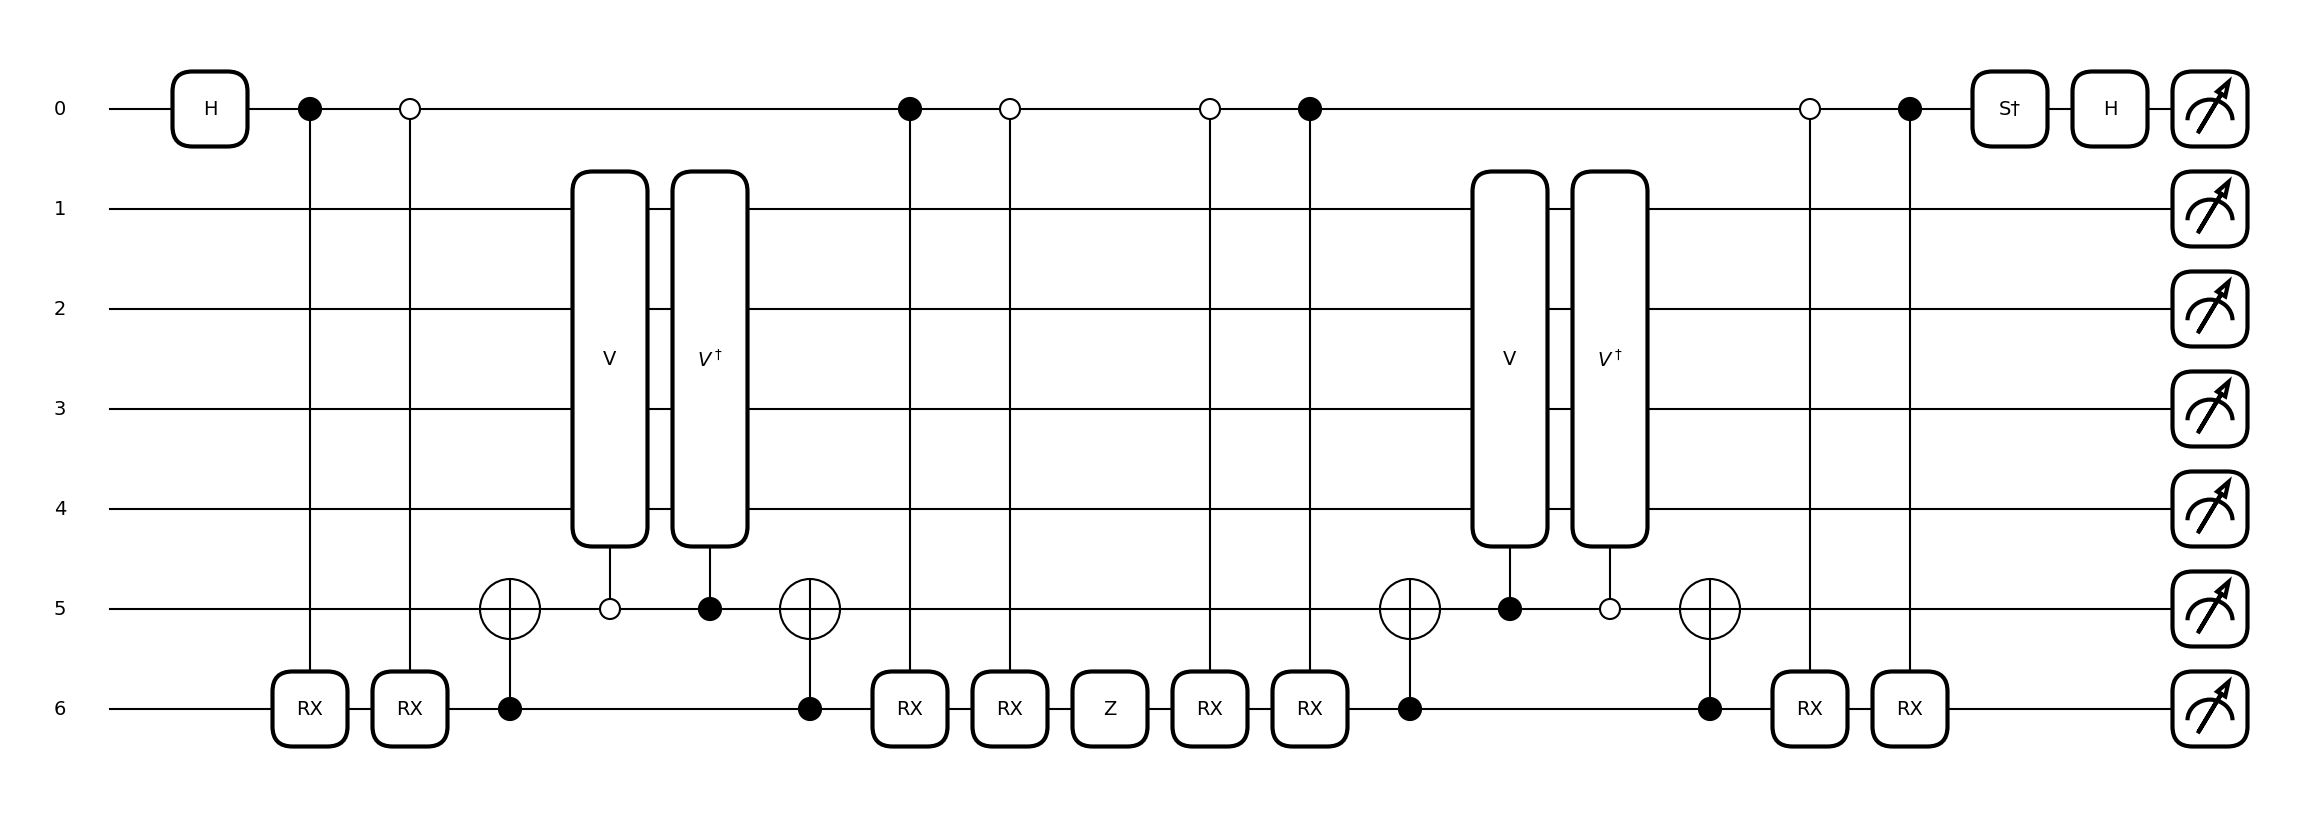

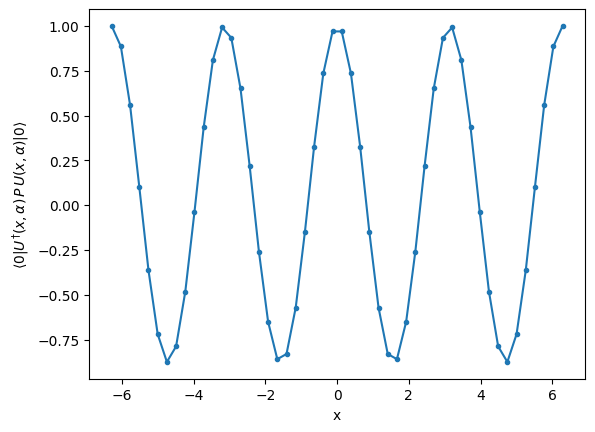

Sweeping random seeds:   0%|          | 0/10 [00:00<?, ?it/s]

Computing kernel (upper triangle):   0%|          | 0/40 [00:00<?, ?it/s]

Computing test kernel:   0%|          | 0/10 [00:00<?, ?it/s]

Computing kernel (upper triangle):   0%|          | 0/40 [00:00<?, ?it/s]

Computing test kernel:   0%|          | 0/10 [00:00<?, ?it/s]

...

Computing test kernel:   0%|          | 0/10 [00:00<?, ?it/s]

Computing kernel (upper triangle):   0%|          | 0/40 [00:00<?, ?it/s]

Computing test kernel:   0%|          | 0/10 [00:00<?, ?it/s]

Computing kernel (upper triangle):   0%|          | 0/40 [00:00<?, ?it/s]

Computing test kernel:   0%|          | 0/10 [00:00<?, ?it/s]

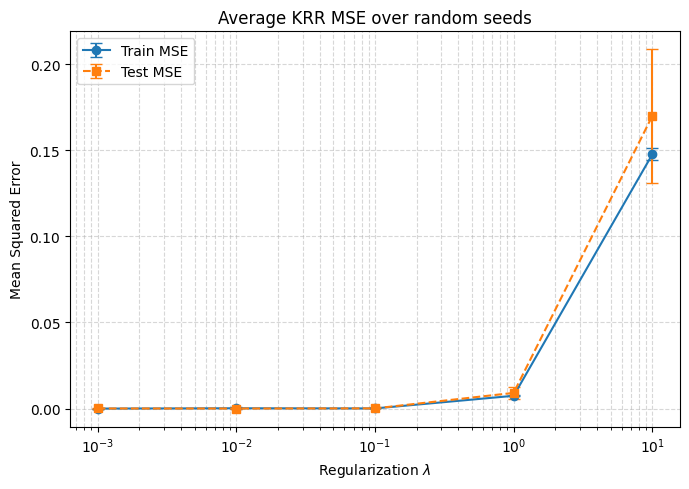

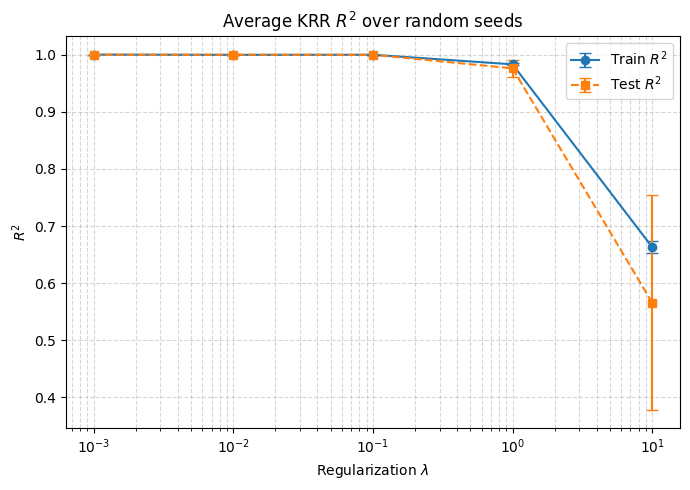

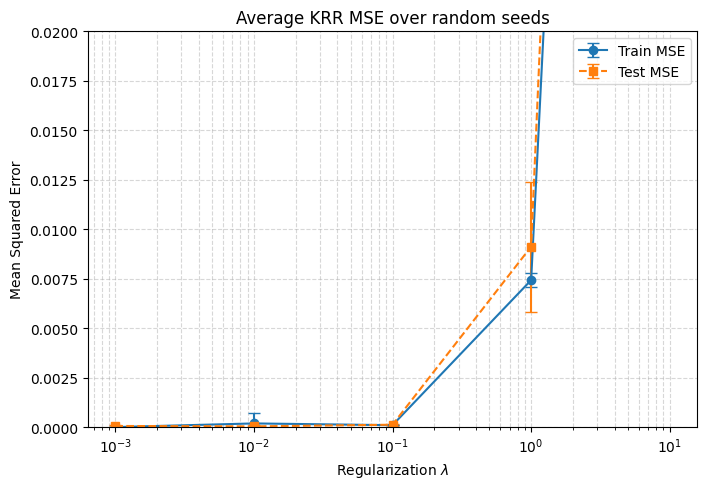

NameError: name 'train_ratios' is not defined

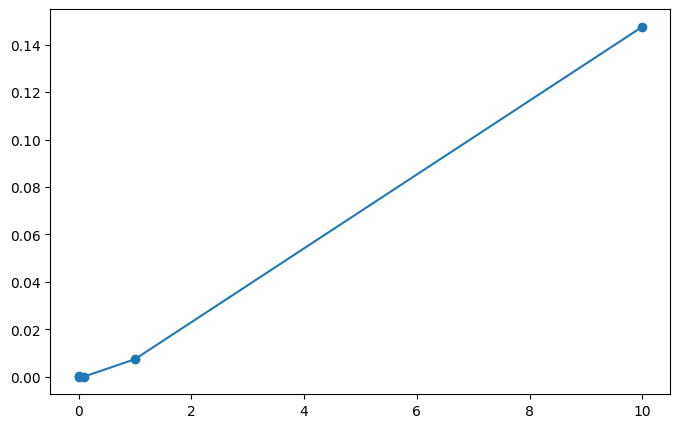

In [2]:
import pennylane as qml
import numpy as np


from tqdm.notebook import tqdm
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_squared_error, r2_score


SEED = 42
np.random.seed(SEED)


# Wrapper gates for controlled Adders
class V(qml.operation.Operation):
    num_params = 2
    par_domain = "R"
    def __init__(self, value, wires, mod):
        super().__init__(value, mod, wires=wires)

    def decomposition(self):
        # Actual gate: controlled Adder
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]

# Adjoint version
class Vdagger(V):
    def __name__(self):
        return "V†"

    def decomposition(self):
        return [qml.Adder(self.parameters[0], x_wires=self.wires, mod=self.parameters[1])]
Vdagger.__name__ = r"$V^\dagger$"

dim_x=1
dim_alpha=1
observable_terms=['Z0']

# build_P function
def build_P(observable_terms):
    import pennylane as qml
    P = None
    for term in observable_terms:
        pieces = term.replace('+',' ').split()
        local = None
        for p in pieces:
            op = p[0].upper()
            idx = int(p[1:])
            t = getattr(qml, f'Pauli{op}')(idx)
            local = t if local is None else local @ t
        P = local if P is None else P + local
    return P if P is not None else qml.PauliZ(0)

def build_shifted_P(observable_terms, circ_offset):
            shifted_terms = []
            for term in observable_terms:
                parts = term.replace('+', ' ').split()
                new_parts = []
                for p in parts:
                    op = p[0].upper()
                    idx = int(p[1:])
                    new_parts.append(f"{op}{idx + circ_offset}")
                shifted_terms.append(" ".join(new_parts))
            return build_P(shifted_terms)
        
n_kernel=1; freq_register_sizes={0: 4}; n_freq=4
n_anc=1; n_circ=1; n_total=7
kernel_offset=0; freq_offset=1
anc_offset=5; circ_offset=6
shots = 1000000

dev=qml.device('default.qubit', wires=n_total, shots = shots, seed = SEED)
dev_analytic = qml.device('default.qubit', wires=n_total, shots=None)  # analytic

P_shifted = build_shifted_P(observable_terms, circ_offset=circ_offset)

def U(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)

@qml.qnode(dev_analytic)
def U_return_expval(x, α):
    U(x,α)
    return qml.expval(P_shifted)

@qml.qnode(dev)
def UPU(x, α):
    qml.RX(x[0], wires=6)
    qml.RZ(α[0], wires=6)
    qml.RX(x[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)
    # user-provided adjoint (trimmed prefix)
    qml.RX(-x[0], wires=6)
    qml.RZ(-α[0], wires=6)
    qml.RX(-x[0], wires=6)
    return qml.state()

def AuPAu(x, x1, α, part = "real"):
    qml.Hadamard(wires=0)

    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [0])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [1])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[1])(x[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[0])(x1[0], wires=6)
    P = build_shifted_P(observable_terms,circ_offset)

    # Adjoint – reverse of duplicated U
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    qml.CNOT(wires=(6,5))
    qml.ctrl(V, control = 5, control_values = [1])( value = 1, wires=[1, 2, 3, 4], mod=2**4)
    qml.ctrl(Vdagger, control = 5, control_values = [0])( value = -1, wires=[1, 2, 3, 4], mod=2**4)
    qml.CNOT(wires=(6,5))
    qml.ctrl(qml.RX, control=0, control_values=[0])(-x1[0], wires=6)
    qml.ctrl(qml.RX, control=0, control_values=[1])(-x[0], wires=6)
    
    if part == "imag":
        qml.adjoint(qml.S)(wires = 0)
        
    qml.Hadamard(wires=0)


@qml.qnode(dev)
def AuPAu_sample(x, x1, α, part="real"):
    AuPAu(x, x1, α, part)   # run your circuit
    return qml.sample(wires=range(n_total))


# Example caller
x0=np.zeros(dim_x); x1=np.copy(x0); α0=np.zeros(dim_alpha)
qml.draw_mpl(U_return_expval)(x0, α0); qml.draw_mpl(UPU)(x0, α0); qml.draw_mpl(AuPAu_sample)(x0, x1, α0); qml.draw_mpl(AuPAu_sample)(x0, x1, α0,part = "imag");
plt.show();


# def conditional_Z_kernel(x, x1, α):
#     samples = AuPAu_sample(x, x1, α)

#     # Extract each register
#     kernel = samples[:, kernel_offset]     # wire 0
#     anc = samples[:, anc_offset]           # anc wire
#     circ = samples[:, circ_offset]         # circ wire

#     # Condition: anc=0 and circ=0
#     mask = (anc == 0) & (circ == 0)
#     conditioned = kernel[mask]

#     total = shots
#     kept = conditioned.shape[0]

#     if kept == 0:
#         return {
#             "total_shots": total,
#             "kept_shots": 0,
#             "expectation": None,
#         }

#     # convert bits to Z eigenvalues (+1 for 0, -1 for 1)
#     zvals = 1 - 2*conditioned       # maps 0→+1, 1→−1

#     return {
#         "total_shots": total,
#         "kept_shots": kept,
#         "fraction_kept": kept / total,
#         "expectation": np.mean(zvals),
#     }

def conditional_inner_product(x, x1, α, part="real"):
    samples = AuPAu_sample(x, x1, α, part)

    kernel = samples[:, kernel_offset]
    anc = samples[:, anc_offset]
    circ = samples[:, circ_offset]

    mask = (anc == 0) & (circ == 0)
    conditioned = kernel[mask]

    if conditioned.size == 0:
        return 0.0

    zvals = 1 - 2 * conditioned
    expectation = np.mean(zvals)
    fraction_kept = conditioned.size / shots

    return fraction_kept * expectation


def complex_kernel(x, x1, α):
    re = conditional_inner_product(x, x1, α, part="real")
    im = conditional_inner_product(x, x1, α, part="imag")
    return re + 1j * im


# -------------------------------------------------------
# Generate dataset
# -------------------------------------------------------
def generate_labels(X, α):
    Y = np.array([U_return_expval(x_arr, α) for x_arr in X])
    return Y


# Generated X (list of numpy arrays):
X = [np.array([-6.29]), np.array([-6.033265306122449]), np.array([-5.776530612244898]), np.array([-5.519795918367347]), np.array([-5.263061224489796]), np.array([-5.006326530612245]), np.array([-4.749591836734694]), np.array([-4.492857142857143]), np.array([-4.236122448979591]), np.array([-3.9793877551020405]), np.array([-3.7226530612244897]), np.array([-3.4659183673469385]), np.array([-3.2091836734693873]), np.array([-2.9524489795918365]), np.array([-2.6957142857142853]), np.array([-2.4389795918367345]), np.array([-2.1822448979591833]), np.array([-1.9255102040816325]), np.array([-1.6687755102040809]), np.array([-1.4120408163265301]), np.array([-1.1553061224489793]), np.array([-0.8985714285714277]), np.array([-0.6418367346938769]), np.array([-0.38510204081632615]), np.array([-0.1283673469387745]), np.array([0.12836734693877627]), np.array([0.38510204081632704]), np.array([0.6418367346938778]), np.array([0.8985714285714295]), np.array([1.1553061224489802]), np.array([1.412040816326531]), np.array([1.6687755102040827]), np.array([1.9255102040816334]), np.array([2.182244897959184]), np.array([2.438979591836735]), np.array([2.6957142857142857]), np.array([2.9524489795918383]), np.array([3.209183673469389]), np.array([3.46591836734694]), np.array([3.7226530612244906]), np.array([3.9793877551020413]), np.array([4.236122448979592]), np.array([4.492857142857145]), np.array([4.749591836734695]), np.array([5.006326530612246]), np.array([5.263061224489797]), np.array([5.519795918367348]), np.array([5.7765306122448985]), np.array([6.033265306122451]), np.array([6.29])]
alpha = np.array([0.5])
Y = generate_labels(X,alpha)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, shuffle = True, random_state = SEED)


if dim_x == 1:
    plt.plot(X, Y, ".-")
    plt.xlabel("x")
    plt.ylabel(r"$\langle 0 | U^{\dagger}(x,\alpha)\, P\, U(x,\alpha) | 0 \rangle$")
    plt.show();


# -------------------------------------------------------
# FUNCTION — compute train kernel (precomputed kernel)
# -------------------------------------------------------
# def compute_kernel_matrix_train(X_train, α):
#     n = len(X_train)
#     K = np.zeros((n, n), dtype=complex)

#     for i in tqdm(range(n), desc="Computing train kernel"):
#         for j in range(n):
#             K[i, j] = complex_kernel(X_train[i], X_train[j], α)

#     return K
def compute_kernel_matrix_train(X_train, α):
    n = len(X_train)
    K = np.zeros((n, n), dtype=complex)

    for i in tqdm(range(n), desc="Computing kernel (upper triangle)"):
        for j in range(i, n):
            val = complex_kernel(X_train[i], X_train[j], α)
            K[i, j] = val
            K[j, i] = np.conj(val)

    # Enforce Hermiticity (shot-noise cleanup)
    K = 0.5 * (K + K.conj().T)
    return K



# -------------------------------------------------------
# FUNCTION — compute test kernel (test × train)
# -------------------------------------------------------
def compute_kernel_matrix_test(X_test, X_train, α):
    n_test = len(X_test)
    n_train = len(X_train)
    K = np.zeros((n_test, n_train), dtype=complex)

    for i in tqdm(range(n_test), desc="Computing test kernel"):
        for j in range(n_train):
            K[i, j] = complex_kernel(X_test[i], X_train[j], α)

    return K


# -------------------------------------------------------
# KERNEL COMPUTATION WITH TIMING
# -------------------------------------------------------
# start_train = time.time()
# K_train = compute_kernel_matrix_train(X_train, alpha)
# end_train = time.time()
# print(f"\nTime to compute TRAIN kernel = {end_train - start_train:.3f} seconds\n")

# start_test = time.time()
# K_test = compute_kernel_matrix_test(X_test, X_train, alpha)
# end_test = time.time()
# print(f"\nTime to compute TEST kernel = {end_test - start_test:.3f} seconds\n")

def manual_krr_fit(K_train, y_train, lam):
    """
    Manual kernel ridge regression fit.
    Works for real or complex kernels.
    """
    n = K_train.shape[0]
    return np.linalg.solve(K_train + lam * np.eye(n), y_train)


def manual_krr_predict(K_test, coeffs):
    """
    Predict using kernel matrix and fitted coefficients.
    """
    return (K_test @ coeffs).real


# -------------------------------------------------------
# MANUAL KERNEL RIDGE REGRESSION
# -------------------------------------------------------
SEEDS = [42, 7, 123, 99, 2025, 0, 5, 88, 314, 256]

lambdas = [1e-3, 1e-2, 1e-1, 1, 1e1]
n_seeds = len(SEEDS)
n_lam = len(lambdas)

train_mse_all = np.zeros((n_seeds, n_lam))
test_mse_all  = np.zeros((n_seeds, n_lam))
train_r2_all  = np.zeros((n_seeds, n_lam))
test_r2_all   = np.zeros((n_seeds, n_lam))


for s_idx, SEED in enumerate(tqdm(SEEDS, desc="Sweeping random seeds")):

    np.random.seed(SEED)

    dev = qml.device(
        'default.qubit',
        wires=n_total,
        shots=shots,
        seed=SEED
    )

    # Rebind QNodes to the new device
    AuPAu_sample = qml.QNode(AuPAu_sample.func, dev)
    
    # Train / test split
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, shuffle=True, random_state=SEED
    )

    # Compute kernels
    K_train = compute_kernel_matrix_train(X_train, alpha)
    K_test  = compute_kernel_matrix_test(X_test, X_train, alpha)

    # Lambda sweep
    for l_idx, lam in enumerate(lambdas):

        coeffs = manual_krr_fit(K_train, Y_train, lam)

        Y_train_pred = manual_krr_predict(K_train, coeffs)
        Y_test_pred  = manual_krr_predict(K_test, coeffs)

        train_mse_all[s_idx, l_idx] = mean_squared_error(Y_train, Y_train_pred)
        test_mse_all[s_idx, l_idx]  = mean_squared_error(Y_test, Y_test_pred)

        train_r2_all[s_idx, l_idx]  = r2_score(Y_train, Y_train_pred)
        test_r2_all[s_idx, l_idx]   = r2_score(Y_test, Y_test_pred)

train_mse_mean = train_mse_all.mean(axis=0)
train_mse_std  = train_mse_all.std(axis=0)

test_mse_mean  = test_mse_all.mean(axis=0)
test_mse_std   = test_mse_all.std(axis=0)

train_r2_mean  = train_r2_all.mean(axis=0)
train_r2_std   = train_r2_all.std(axis=0)

test_r2_mean   = test_r2_all.mean(axis=0)
test_r2_std    = test_r2_all.std(axis=0)


plt.figure(figsize=(7,5))

plt.errorbar(
    lambdas, train_mse_mean, yerr=train_mse_std,
    fmt="o-", capsize=4, label="Train MSE"
)
plt.errorbar(
    lambdas, test_mse_mean, yerr=test_mse_std,
    fmt="s--", capsize=4, label="Test MSE"
)

plt.xscale("log")
plt.xlabel(r"Regularization $\lambda$")
plt.ylabel("Mean Squared Error")
plt.title("Average KRR MSE over random seeds")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()




plt.figure(figsize=(7,5))

plt.errorbar(
    lambdas, train_r2_mean, yerr=train_r2_std,
    fmt="o-", capsize=4, label="Train $R^2$"
)
plt.errorbar(
    lambdas, test_r2_mean, yerr=test_r2_std,
    fmt="s--", capsize=4, label="Test $R^2$"
)

plt.xscale("log")
plt.xlabel(r"Regularization $\lambda$")
plt.ylabel(r"$R^2$")
plt.title("Average KRR $R^2$ over random seeds")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


plt.figure(figsize=(7,5))

plt.errorbar(
    lambdas, train_mse_mean, yerr=train_mse_std,
    fmt="o-", capsize=4, label="Train MSE"
)
plt.errorbar(
    lambdas, test_mse_mean, yerr=test_mse_std,
    fmt="s--", capsize=4, label="Test MSE"
)

plt.xscale("log")
plt.xlabel(r"Regularization $\lambda$")
plt.ylabel("Mean Squared Error")
plt.title("Average KRR MSE over random seeds")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.ylim(0,0.02)
plt.show()

plt.figure(figsize=(8,5))

# Train MSE
plt.plot(lambdas, train_mse_mean, "o-", label="Train MSE")
plt.fill_between(train_ratios,
                 train_mse_mean - train_mse_std,
                 train_mse_mean + train_mse_std,
                 alpha=0.25)

# Test MSE
plt.plot(lambdas, test_mse_mean, "s-", label="Test MSE")
plt.fill_between(train_ratios,
                 test_mse_mean - test_mse_std,
                 test_mse_mean + test_mse_std,
                 alpha=0.25)

plt.xlabel(r"Regularization $\lambda$")
plt.ylabel("Average MSE")
plt.title("Average KRR MSE over random seeds")
plt.legend()
plt.grid(True)
plt.show()

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)

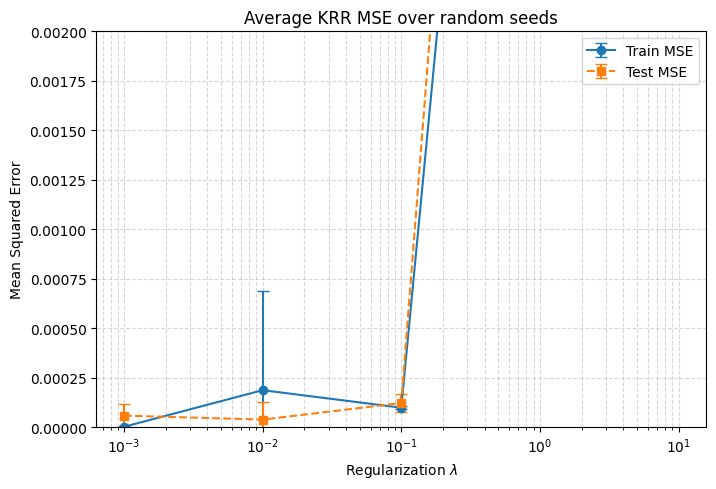

In [3]:

plt.figure(figsize=(7,5))

plt.errorbar(
    lambdas, train_mse_mean, yerr=train_mse_std,
    fmt="o-", capsize=4, label="Train MSE"
)
plt.errorbar(
    lambdas, test_mse_mean, yerr=test_mse_std,
    fmt="s--", capsize=4, label="Test MSE"
)

plt.xscale("log")
plt.xlabel(r"Regularization $\lambda$")
plt.ylabel("Mean Squared Error")
plt.title("Average KRR MSE over random seeds")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.ylim(0,0.002)
plt.show()


In [5]:


print("Train MSE:", train_mse_mean)
print("Test MSE:", test_mse_mean)

Train MSE: [1.66426904e-06 1.86694178e-04 9.81563819e-05 7.42874927e-03
 1.47542180e-01]
Test MSE: [5.83062868e-05 3.80526889e-05 1.21837110e-04 9.11954404e-03
 1.69846493e-01]


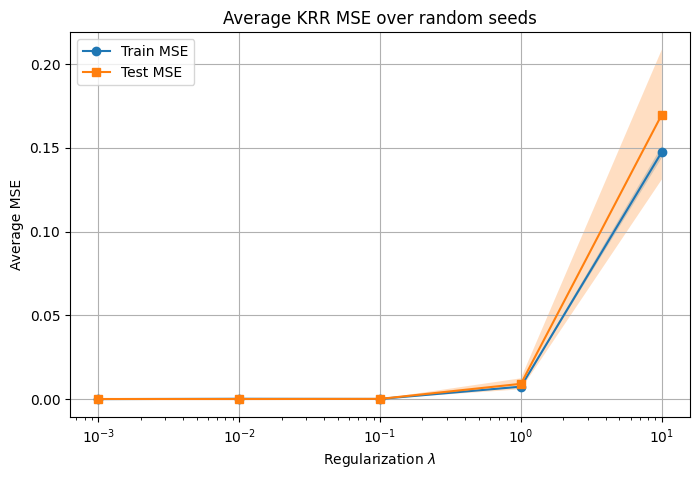

In [8]:

plt.figure(figsize=(8,5))

# Train MSE
plt.plot(lambdas, train_mse_mean, "o-", label="Train MSE")
plt.fill_between(lambdas,
                 train_mse_mean - train_mse_std,
                 train_mse_mean + train_mse_std,
                 alpha=0.25)

# Test MSE
plt.plot(lambdas, test_mse_mean, "s-", label="Test MSE")
plt.fill_between(lambdas,
                 test_mse_mean - test_mse_std,
                 test_mse_mean + test_mse_std,
                 alpha=0.25)
plt.xscale("log")
plt.xlabel(r"Regularization $\lambda$")
plt.ylabel("Average MSE")
plt.title("Average KRR MSE over random seeds")
plt.legend()
plt.grid(True)
plt.show()

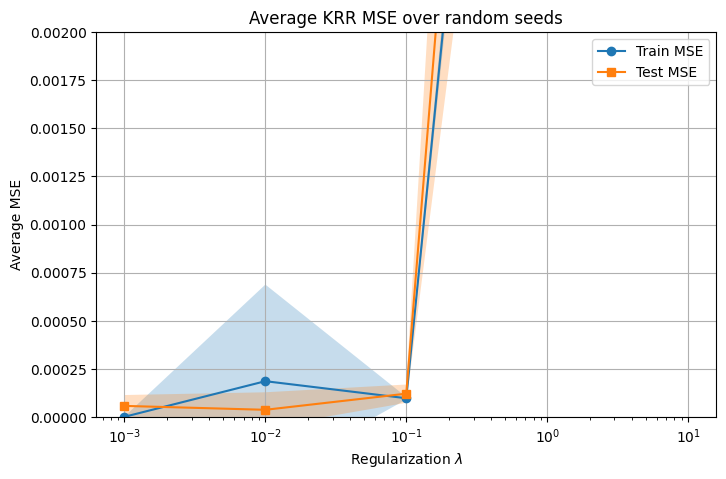

In [9]:

plt.figure(figsize=(8,5))

# Train MSE
plt.plot(lambdas, train_mse_mean, "o-", label="Train MSE")
plt.fill_between(lambdas,
                 train_mse_mean - train_mse_std,
                 train_mse_mean + train_mse_std,
                 alpha=0.25)

# Test MSE
plt.plot(lambdas, test_mse_mean, "s-", label="Test MSE")
plt.fill_between(lambdas,
                 test_mse_mean - test_mse_std,
                 test_mse_mean + test_mse_std,
                 alpha=0.25)
plt.xscale("log")
plt.xlabel(r"Regularization $\lambda$")
plt.ylabel("Average MSE")
plt.title("Average KRR MSE over random seeds")
plt.legend()
plt.grid(True)
plt.ylim(0,0.002)
plt.show()

## 